In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. IMPORTS ET CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models

# Reproductibilité
np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé : {DEVICE}")

Device utilisé : cuda


CHARGEMENT DES DONNÉES
Datasets chargés : ['Sep_clean', 'Sep_noisy', 'NonSep_clean', 'NonSep_noisy']
  Sep_clean: 569 points | +1: 212 | -1: 357
  Sep_noisy: 303 points | +1: 165 | -1: 138
  NonSep_clean: 300 points | +1: 150 | -1: 150
  NonSep_noisy: 891 points | +1: 342 | -1: 549

[TP1-V] Visualisation des 4 datasets


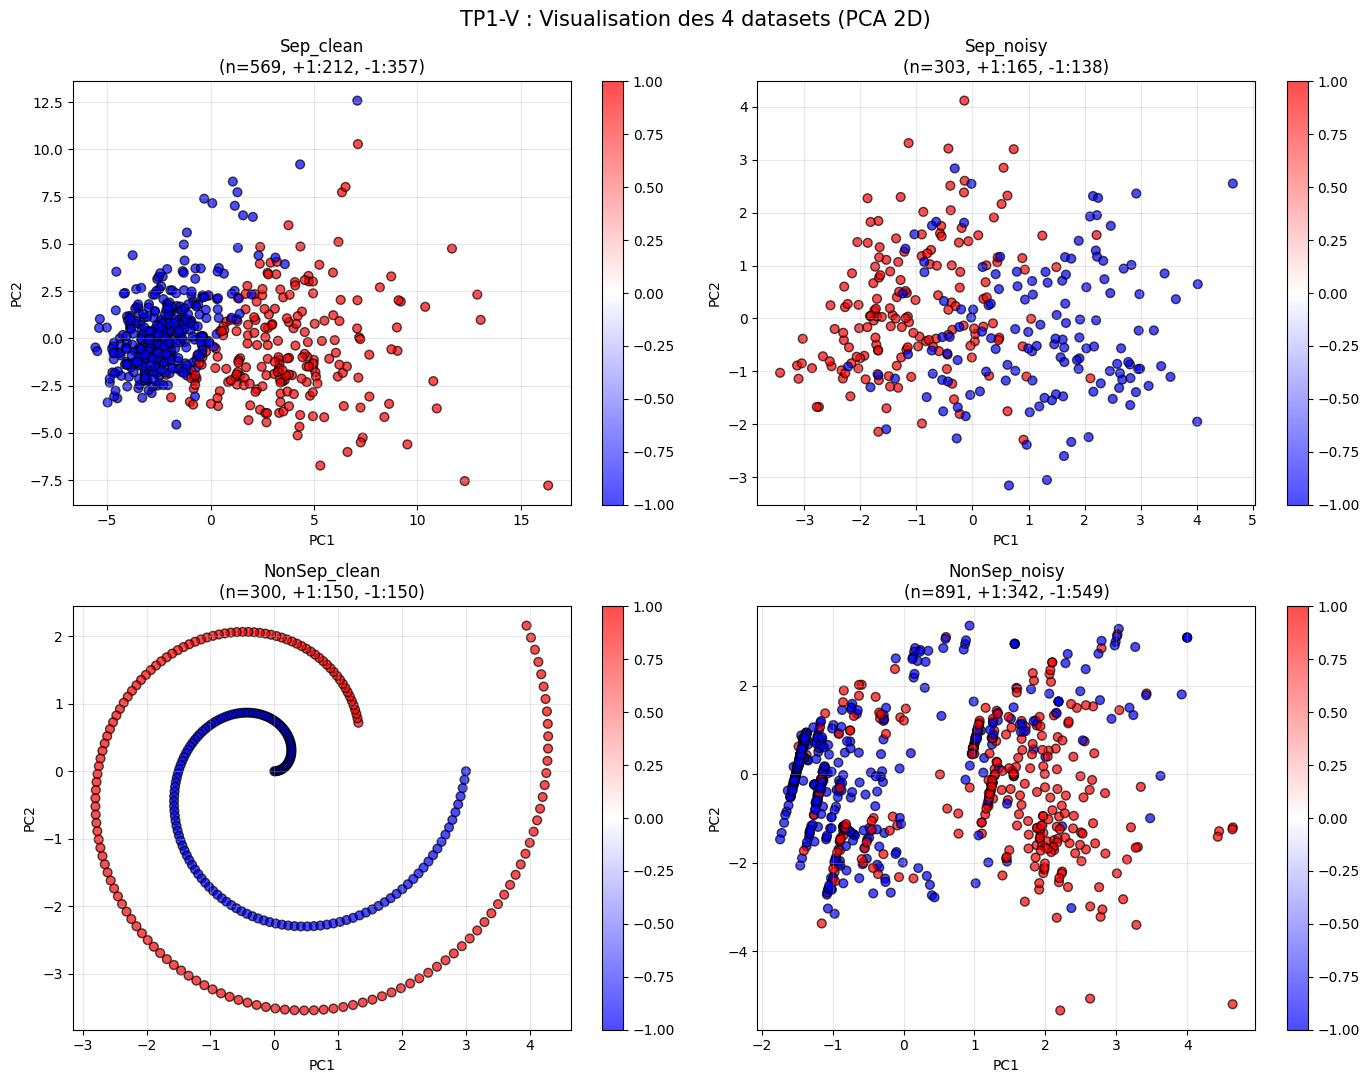

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — DONNÉES : CHARGEMENT ET VISUALISATION (TP1-V)
# ─────────────────────────────────────────────────────────────────────────────

def load_and_prepare_datasets():
    """
    Charge 4 datasets de classification binaire, réduits à 2D via PCA.
    Labels : y ∈ {-1, +1}
    """
    datasets = {}

    # 1. Sep_clean → Breast Cancer Wisconsin (séparable, propre)
    url_bc = "https://raw.githubusercontent.com/pkmklong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv"
    df = pd.read_csv(url_bc)
    df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': -1})
    X = df.drop('diagnosis', axis=1).values
    y = df['diagnosis'].values
    X = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    datasets["Sep_clean"] = (X, y)

    # 2. Sep_noisy → Heart Disease (séparable + bruit)
    url_heart = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
    df = pd.read_csv(url_heart)
    y = np.where(df['target'].values == 0, -1, 1)
    features_df = df.drop('target', axis=1)
    num_cols = features_df.select_dtypes(include=np.number).columns
    features_df[num_cols] = features_df[num_cols].fillna(features_df[num_cols].median())
    X = features_df[num_cols].values
    X = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    datasets["Sep_noisy"] = (X, y)

    # 3. NonSep_clean → Spirales synthétiques (non-linéaire)
    n = 300
    r = np.linspace(0, 3, n // 2)
    theta = np.linspace(0, 2 * np.pi, n // 2)
    X_pos = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    X_neg = np.stack([(r + 1.5) * np.cos(theta + 0.5),
                      (r + 1.5) * np.sin(theta + 0.5)], axis=1)
    X = np.vstack([X_pos, X_neg])
    y = np.array([-1] * (n // 2) + [1] * (n // 2))
    datasets["NonSep_clean"] = (X, y)

    # 4. NonSep_noisy → Titanic (réel, non séparable)
    url_tit = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url_tit).dropna(subset=['Survived'])
    y = np.where(df['Survived'].values == 0, -1, 1)
    numeric = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
    X_num = df[numeric].fillna(df[numeric].median()).values
    X_cat = pd.get_dummies(df[['Sex']]).values
    X = np.hstack([X_num, X_cat])
    X = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    datasets["NonSep_noisy"] = (X, y)

    return datasets

print("=" * 60)
print("CHARGEMENT DES DONNÉES")
print("=" * 60)
datasets = load_and_prepare_datasets()
names = list(datasets.keys())
print(f"Datasets chargés : {names}")
for name, (X, y) in datasets.items():
    n_pos = (y == 1).sum()
    n_neg = (y == -1).sum()
    print(f"  {name}: {X.shape[0]} points | +1: {n_pos} | -1: {n_neg}")

# ─── TP1-V : Visualisation ───────────────────────────────────────────────────
print("\n[TP1-V] Visualisation des 4 datasets")
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for i, (name, (X, y)) in enumerate(datasets.items()):
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
                         edgecolor='k', alpha=0.7, s=40)
    ax.set_title(f"{name}\n(n={X.shape[0]}, +1:{(y==1).sum()}, -1:{(y==-1).sum()})",
                 fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax)
plt.suptitle("TP1-V : Visualisation des 4 datasets (PCA 2D)", fontsize=15)
plt.tight_layout()
plt.savefig("01_visualisation_datasets.png", dpi=150, bbox_inches='tight')
plt.show()



[TP1-CN] Covering Number adaptatif par dataset
  Sep_clean: étendue=21.88, N(ε=10%)=36, n_min≈180, n_actuel=569 → ✓ suffisant
  Sep_noisy: étendue=8.08, N(ε=10%)=37, n_min≈185, n_actuel=303 → ✓ suffisant
  NonSep_clean: étendue=7.09, N(ε=10%)=42, n_min≈210, n_actuel=300 → ✓ suffisant
  NonSep_noisy: étendue=8.70, N(ε=10%)=33, n_min≈165, n_actuel=891 → ✓ suffisant


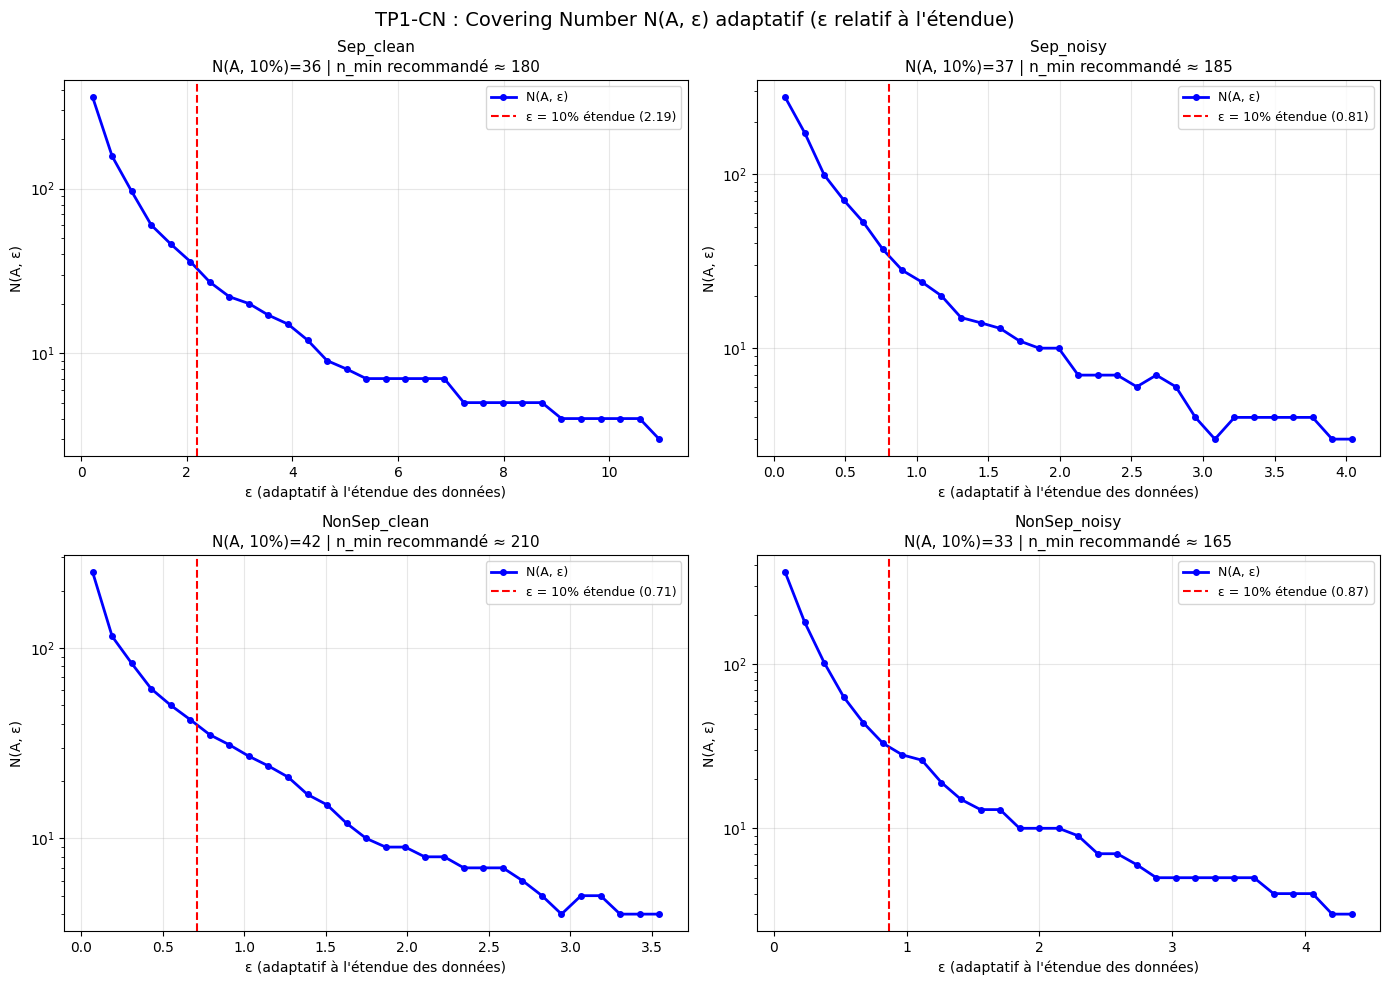

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — COVERING NUMBER ADAPTATIF (TP1-CN)
# ─────────────────────────────────────────────────────────────────────────────

def adaptive_covering_number(X, eps_values):
    """
    Calcule le covering number N(A, ε) pour un ensemble X ⊂ R².
    N(A, ε) = nombre de boules de rayon ε nécessaires pour couvrir A.
    Algorithme glouton : on place un centre tant qu'il reste un point non couvert.
    """
    covering_numbers = []
    for eps in eps_values:
        remaining = X.copy()
        centers = []
        while len(remaining) > 0:
            # Choisir le premier point non couvert comme nouveau centre
            c = remaining[0]
            centers.append(c)
            # Supprimer tous les points dans la boule B(c, eps)
            dists = np.linalg.norm(remaining - c, axis=1)
            remaining = remaining[dists > eps]
        covering_numbers.append(len(centers))
    return np.array(covering_numbers)

print("\n[TP1-CN] Covering Number adaptatif par dataset")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (name, (X, y)) in enumerate(datasets.items()):
    ax = axes[i // 2, i % 2]

    # Plage adaptative de ε basée sur l'étendue des données
    x_range = X[:, 0].max() - X[:, 0].min()
    y_range = X[:, 1].max() - X[:, 1].min()
    data_scale = max(x_range, y_range)

    # ε adaptatif : de 1% à 50% de l'étendue des données
    eps_relative = np.linspace(0.01, 0.5, 30)
    eps_values = eps_relative * data_scale

    CN = adaptive_covering_number(X, eps_values)

    ax.plot(eps_values, CN, 'b-o', markersize=4, linewidth=2, label='N(A, ε)')
    ax.axvline(x=0.1 * data_scale, color='r', linestyle='--',
               label=f'ε = 10% étendue ({0.1*data_scale:.2f})')

    # Taille minimale d'échantillon recommandée
    idx_ref = np.argmin(np.abs(eps_relative - 0.1))
    n_min = int(CN[idx_ref] * 5)  # 5 points par cellule minimum
    ax.set_title(f"{name}\nN(A, 10%)={CN[idx_ref]} | n_min recommandé ≈ {n_min}", fontsize=11)
    ax.set_xlabel("ε (adaptatif à l'étendue des données)")
    ax.set_ylabel("N(A, ε)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    print(f"  {name}: étendue={data_scale:.2f}, N(ε=10%)={CN[idx_ref]}, "
          f"n_min≈{n_min}, n_actuel={X.shape[0]} → "
          f"{'✓ suffisant' if X.shape[0] >= n_min else '✗ insuffisant'}")

plt.suptitle("TP1-CN : Covering Number N(A, ε) adaptatif (ε relatif à l'étendue)", fontsize=14)
plt.tight_layout()
plt.savefig("02_covering_number.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — ARCHITECTURES CNN (ResNet-50 adapté & VGG-19 adapté)
# ─────────────────────────────────────────────────────────────────────────────

class CNN1_ResNet50_Adapted(nn.Module):

    def __init__(self, input_dim=2):
        super().__init__()
        # Projection initiale
        self.embed = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        # Bloc résiduel 1
        self.res1_main = nn.Sequential(
            nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 64), nn.BatchNorm1d(64)
        )
        # Bloc résiduel 2
        self.res2_main = nn.Sequential(
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128)
        )
        self.res2_skip = nn.Linear(64, 128)

        # Bloc résiduel 3
        self.res3_main = nn.Sequential(
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256)
        )
        self.res3_skip = nn.Linear(128, 256)

        # Tête de sortie
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.embed(x)
        # Bloc 1 (même dimension → skip trivial)
        x = self.relu(x + self.res1_main(x))
        # Bloc 2 (projection skip)
        x = self.relu(self.res2_skip(x) + self.res2_main(x))
        # Bloc 3 (projection skip)
        x = self.relu(self.res3_skip(x) + self.res3_main(x))
        return self.head(x).squeeze(-1)


In [5]:
class CNN2_VGG19_Adapted(nn.Module):

    def __init__(self, input_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            # Bloc 1
            nn.Linear(input_dim, 32), nn.Tanh(),
            # Bloc 2
            nn.Linear(32, 64), nn.Tanh(),
            # Bloc 3
            nn.Linear(64, 128), nn.Tanh(), nn.Dropout(0.2),
            # Bloc 4
            nn.Linear(128, 256), nn.Tanh(),
            # Bloc 5
            nn.Linear(256, 128), nn.Tanh(), nn.Dropout(0.2),
            # Bloc 6
            nn.Linear(128, 64), nn.Tanh(),
            # Tête
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)



In [6]:
print("\n[CNN] Architectures CNN1 (ResNet-style) et CNN2 (VGG-style)")
model_cnn1 = CNN1_ResNet50_Adapted(input_dim=2)
model_cnn2 = CNN2_VGG19_Adapted(input_dim=2)
n_params_1 = sum(p.numel() for p in model_cnn1.parameters())
n_params_2 = sum(p.numel() for p in model_cnn2.parameters())
print(f"  CNN1 (ResNet-50 adapté) : {n_params_1:,} paramètres")
print(f"  CNN2 (VGG-19 adapté)    : {n_params_2:,} paramètres")



[CNN] Architectures CNN1 (ResNet-style) et CNN2 (VGG-style)
  CNN1 (ResNet-50 adapté) : 208,449 paramètres
  CNN2 (VGG-19 adapté)    : 84,769 paramètres


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — FONCTION DE COÛT ET SOUS-GRADIENT (TP2-SG)
# ─────────────────────────────────────────────────────────────────────────────
# On implémente TOUT de A à Z, sans utiliser de fonctions prédéfinies de PyTorch
# pour la loss et le sous-gradient.

def hinge_loss_manual(scores, labels):
    """
    Perte Hinge (SVM) : L(θ) = (1/n) Σ max(0, 1 - y_i * s_i)
    Non différentiable en y_i * s_i = 1.
    scores : vecteur s_θ(x_i) ∈ R
    labels : y_i ∈ {-1, +1}
    """
    margins = 1.0 - labels * scores
    losses = torch.clamp(margins, min=0.0)
    return losses.mean()


def hinge_subgradient_manual(scores, labels):
    """
    Sous-gradient de la perte Hinge par rapport à scores :
    ∂L/∂s_i = -y_i / n   si  y_i * s_i < 1
             = 0           si  y_i * s_i > 1
             ∈ [-y_i/n, 0] si  y_i * s_i = 1  (on prend 0 par convention)
    """
    n = scores.shape[0]
    margins = 1.0 - labels * scores
    # Indicateur : 1 si marge > 0 (point mal classé ou dans la zone de marge)
    indicator = (margins > 0).float()
    subgrad = -labels * indicator / n
    return subgrad


In [8]:
def compute_loss_and_subgrad(model, X_t, y_t, lambda_reg=0.0):
    """
    Calcule la perte hinge + régularisation L2, et le sous-gradient total.
    Retourne : loss (scalar), grad_params (liste de tenseurs pour chaque paramètre)
    """
    model.zero_grad()
    scores = model(X_t)
    loss = hinge_loss_manual(scores, y_t)

    # Régularisation L2 manuelle : λ/2 * ||θ||²
    if lambda_reg > 0:
        l2_reg = sum(p.pow(2).sum() for p in model.parameters())
        loss = loss + lambda_reg / 2.0 * l2_reg

    # Backprop pour calculer les gradients (= sous-gradient ici)
    loss.backward()
    return loss.item()


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — LINE SEARCH (TP2-LS : Armijo, Goldstein, Wolfe)
# ─────────────────────────────────────────────────────────────────────────────

def line_search_armijo(model, X_t, y_t, alpha_0=1.0, beta=0.5, c=1e-4, max_iter=20):
    """
    Armijo (backtracking) : α ← α*β tant que f(θ - α*g) > f(θ) - c*α*||g||²
    Garantit la décroissance suffisante (condition Armijo / Wolfe 1ère condition).
    """
    alpha = alpha_0
    loss0 = compute_loss_and_subgrad(model, X_t, y_t)
    grad_norm_sq = sum(p.grad.pow(2).sum().item()
                       for p in model.parameters() if p.grad is not None)

    params_backup = [p.data.clone() for p in model.parameters()]

    for _ in range(max_iter):
        # Appliquer le pas α
        for p in model.parameters():
            if p.grad is not None:
                p.data = p.data - alpha * p.grad

        new_loss = compute_loss_and_subgrad(model, X_t, y_t)

        if new_loss <= loss0 - c * alpha * grad_norm_sq:
            return alpha, new_loss  # Condition satisfaite

        # Restaurer et réduire α
        for p, pb in zip(model.parameters(), params_backup):
            p.data = pb.clone()
        alpha *= beta

    # Appliquer avec α final
    for p in model.parameters():
        if p.grad is not None:
            p.data = p.data - alpha * p.grad
    return alpha, compute_loss_and_subgrad(model, X_t, y_t)

In [10]:
def line_search_goldstein(model, X_t, y_t, alpha_0=1.0, c=0.1, max_iter=20):
    """
    Goldstein : c*α*||g||² ≤ f(θ)-f(θ-α*g) ≤ (1-c)*α*||g||²
    Assure que le pas n'est ni trop petit ni trop grand.
    """
    alpha = alpha_0
    loss0 = compute_loss_and_subgrad(model, X_t, y_t)
    grad_norm_sq = sum(p.grad.pow(2).sum().item()
                       for p in model.parameters() if p.grad is not None)

    params_backup = [p.data.clone() for p in model.parameters()]
    alpha_lo, alpha_hi = 0.0, float('inf')

    for _ in range(max_iter):
        for p in model.parameters():
            if p.grad is not None:
                p.data = p.data - alpha * p.grad
        new_loss = compute_loss_and_subgrad(model, X_t, y_t)
        decrease = loss0 - new_loss

        cond_lo = decrease >= c * alpha * grad_norm_sq       # Armijo
        cond_hi = decrease <= (1 - c) * alpha * grad_norm_sq  # Goldstein upper

        if cond_lo and cond_hi:
            return alpha, new_loss

        for p, pb in zip(model.parameters(), params_backup):
            p.data = pb.clone()

        if not cond_lo:
            alpha_hi = alpha
            alpha = (alpha_lo + alpha_hi) / 2
        else:
            alpha_lo = alpha
            alpha = min(2 * alpha, (alpha_lo + alpha_hi) / 2
                        if alpha_hi < float('inf') else 2 * alpha)

    for p in model.parameters():
        if p.grad is not None:
            p.data = p.data - alpha * p.grad
    return alpha, compute_loss_and_subgrad(model, X_t, y_t)


In [11]:
def line_search_wolfe(model, X_t, y_t, alpha_0=1.0, c1=1e-4, c2=0.9, max_iter=20):
    """
    Wolfe (conditions fortes) :
      1) f(θ-α*g) ≤ f(θ) - c1*α*||g||²  (Armijo)
      2) |<∇f(θ-α*g), g>| ≤ c2*||g||²   (courbure forte)
    """
    alpha = alpha_0
    loss0 = compute_loss_and_subgrad(model, X_t, y_t)
    grads0 = [p.grad.clone() if p.grad is not None else None
              for p in model.parameters()]
    grad_norm_sq = sum(g.pow(2).sum().item() for g in grads0 if g is not None)

    params_backup = [p.data.clone() for p in model.parameters()]

    for _ in range(max_iter):
        for p, g in zip(model.parameters(), grads0):
            if g is not None:
                p.data = p.data - alpha * g

        new_loss = compute_loss_and_subgrad(model, X_t, y_t)
        new_grads = [p.grad.clone() if p.grad is not None else None
                     for p in model.parameters()]
        new_curv = sum((ng * g).sum().item()
                       for ng, g in zip(new_grads, grads0)
                       if ng is not None and g is not None)

        armijo_ok = new_loss <= loss0 - c1 * alpha * grad_norm_sq
        wolfe_ok = abs(new_curv) <= c2 * grad_norm_sq

        if armijo_ok and wolfe_ok:
            return alpha, new_loss

        for p, pb in zip(model.parameters(), params_backup):
            p.data = pb.clone()
        alpha *= 0.5

    for p, g in zip(model.parameters(), grads0):
        if g is not None:
            p.data = p.data - alpha * g
    return alpha, compute_loss_and_subgrad(model, X_t, y_t)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — ENTRAÎNEMENT AVEC COMPARAISON LINE SEARCH (TP2-LS)
# ─────────────────────────────────────────────────────────────────────────────

def train_with_line_search(X_np, y_np, model_class, ls_method='armijo',
                            n_epochs=60, lambda_reg=1e-4):
    """
    Entraîne un modèle avec la méthode de line search spécifiée.
    Retourne l'historique des pertes, précisions et pas utilisés.
    """
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    y_t = torch.FloatTensor(y_np).to(DEVICE)

    model = model_class(input_dim=2).to(DEVICE)

    losses, accs, alphas = [], [], []

    for epoch in range(n_epochs):
        model.train()
        model.zero_grad()
        # Forward + sous-gradient
        scores = model(X_t)
        loss = hinge_loss_manual(scores, y_t)
        if lambda_reg > 0:
            l2 = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + lambda_reg / 2.0 * l2
        loss.backward()

        # Sauvegarde des gradients (sous-gradients)
        grads = [p.grad.clone() if p.grad is not None else torch.zeros_like(p)
                 for p in model.parameters()]

        # Appliquer le pas via line search
        if ls_method == 'armijo':
            alpha, new_loss = line_search_armijo(model, X_t, y_t)
        elif ls_method == 'goldstein':
            alpha, new_loss = line_search_goldstein(model, X_t, y_t)
        elif ls_method == 'wolfe':
            alpha, new_loss = line_search_wolfe(model, X_t, y_t)
        elif ls_method == 'fixed':
            alpha = 0.01
            for p, g in zip(model.parameters(), grads):
                p.data = p.data - alpha * g
            with torch.no_grad():
                scores = model(X_t)
                new_loss = hinge_loss_manual(scores, y_t).item()
        else:
            alpha = 0.01
            for p, g in zip(model.parameters(), grads):
                p.data = p.data - alpha * g
            new_loss = loss.item()
        # Précision
        model.eval()
        with torch.no_grad():
            pred = torch.sign(model(X_t))
            acc = (pred == y_t).float().mean().item()
        losses.append(new_loss)
        accs.append(acc)
        alphas.append(alpha)

    return losses, accs, alphas




[TP2-LS] Comparaison Armijo / Goldstein / Wolfe / Fixed Step


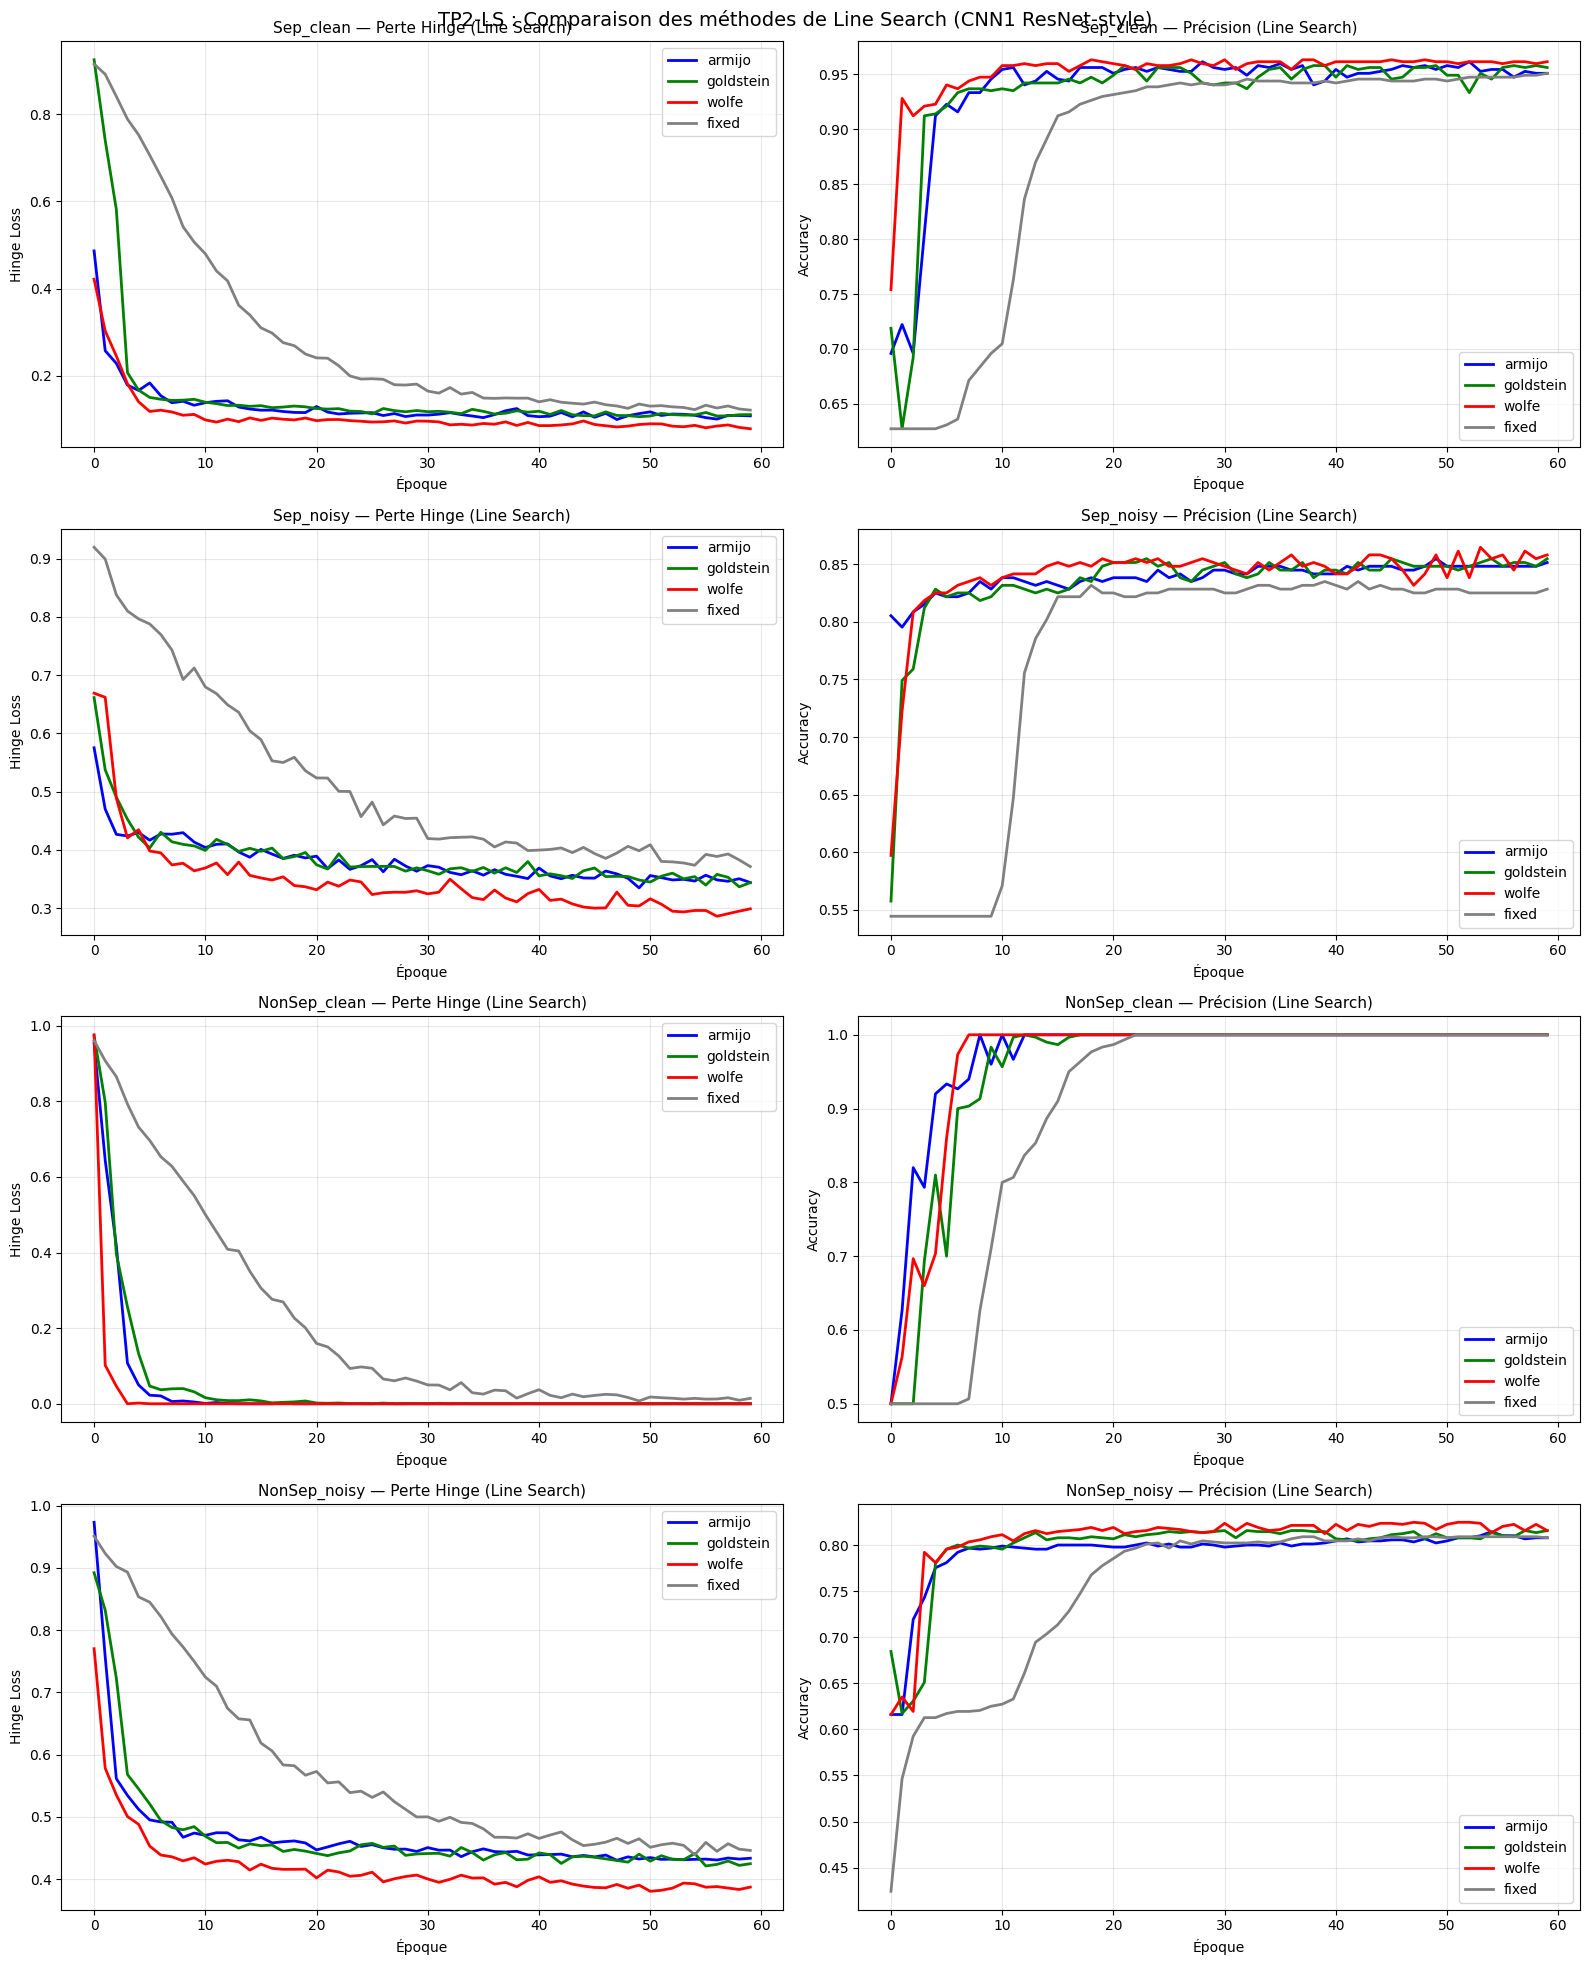


[TP2-LS] Tableau récapitulatif (perte finale et précision finale)
Dataset         Méthode      Loss finale    Acc finale   α moyen
----------------------------------------------------------------------
Sep_clean       armijo       0.1080         95.1%        0.0608
Sep_clean       goldstein    0.1109         95.6%        0.0683
Sep_clean       wolfe        0.0784         96.1%        0.1658
Sep_clean       fixed        0.1212         95.1%        0.0100

Sep_noisy       armijo       0.3440         85.1%        0.0613
Sep_noisy       goldstein    0.3438         85.5%        0.0615
Sep_noisy       wolfe        0.2989         85.8%        0.1420
Sep_noisy       fixed        0.3714         82.8%        0.0100

NonSep_clean    armijo       0.0000         100.0%        0.7385
NonSep_clean    goldstein    0.0000         100.0%        0.2382
NonSep_clean    wolfe        0.0000         100.0%        0.9042
NonSep_clean    fixed        0.0143         100.0%        0.0100

NonSep_noisy    armijo

In [13]:
# ─── Comparaison des Line Search sur chaque dataset ──────────────────────────
print("\n[TP2-LS] Comparaison Armijo / Goldstein / Wolfe / Fixed Step")
ls_methods = ['armijo', 'goldstein', 'wolfe', 'fixed']
ls_colors  = {'armijo': 'blue', 'goldstein': 'green', 'wolfe': 'red', 'fixed': 'gray'}

results_ls = {}  # Stockage pour usage ultérieur

fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))

for row, name in enumerate(names):
    X_np, y_np = datasets[name]
    results_ls[name] = {}

    ax_loss = axes[row, 0]
    ax_acc  = axes[row, 1]

    for ls in ls_methods:
        losses, accs, alphas = train_with_line_search(
            X_np, y_np, CNN1_ResNet50_Adapted, ls_method=ls, n_epochs=60)
        results_ls[name][ls] = (losses, accs, alphas)

        ax_loss.plot(losses, color=ls_colors[ls], label=ls, linewidth=2)
        ax_acc.plot(accs,   color=ls_colors[ls], label=ls, linewidth=2)

    ax_loss.set_title(f"{name} — Perte Hinge (Line Search)", fontsize=11)
    ax_loss.set_xlabel("Époque")
    ax_loss.set_ylabel("Hinge Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.set_title(f"{name} — Précision (Line Search)", fontsize=11)
    ax_acc.set_xlabel("Époque")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

plt.suptitle("TP2-LS : Comparaison des méthodes de Line Search (CNN1 ResNet-style)",
             fontsize=14)
plt.tight_layout()
plt.savefig("03_line_search_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── Tableau récapitulatif Line Search ───────────────────────────────────────
print("\n[TP2-LS] Tableau récapitulatif (perte finale et précision finale)")
print(f"{'Dataset':<15} {'Méthode':<12} {'Loss finale':<14} {'Acc finale':<12} {'α moyen'}")
print("-" * 70)
for name in names:
    for ls in ls_methods:
        losses, accs, alphas = results_ls[name][ls]
        print(f"{name:<15} {ls:<12} {losses[-1]:.4f}         "
              f"{accs[-1]*100:.1f}%        {np.mean(alphas):.4f}")
    print()



[TP2-D] Comparaison direction correcte (-g) vs mauvaise direction (+g)


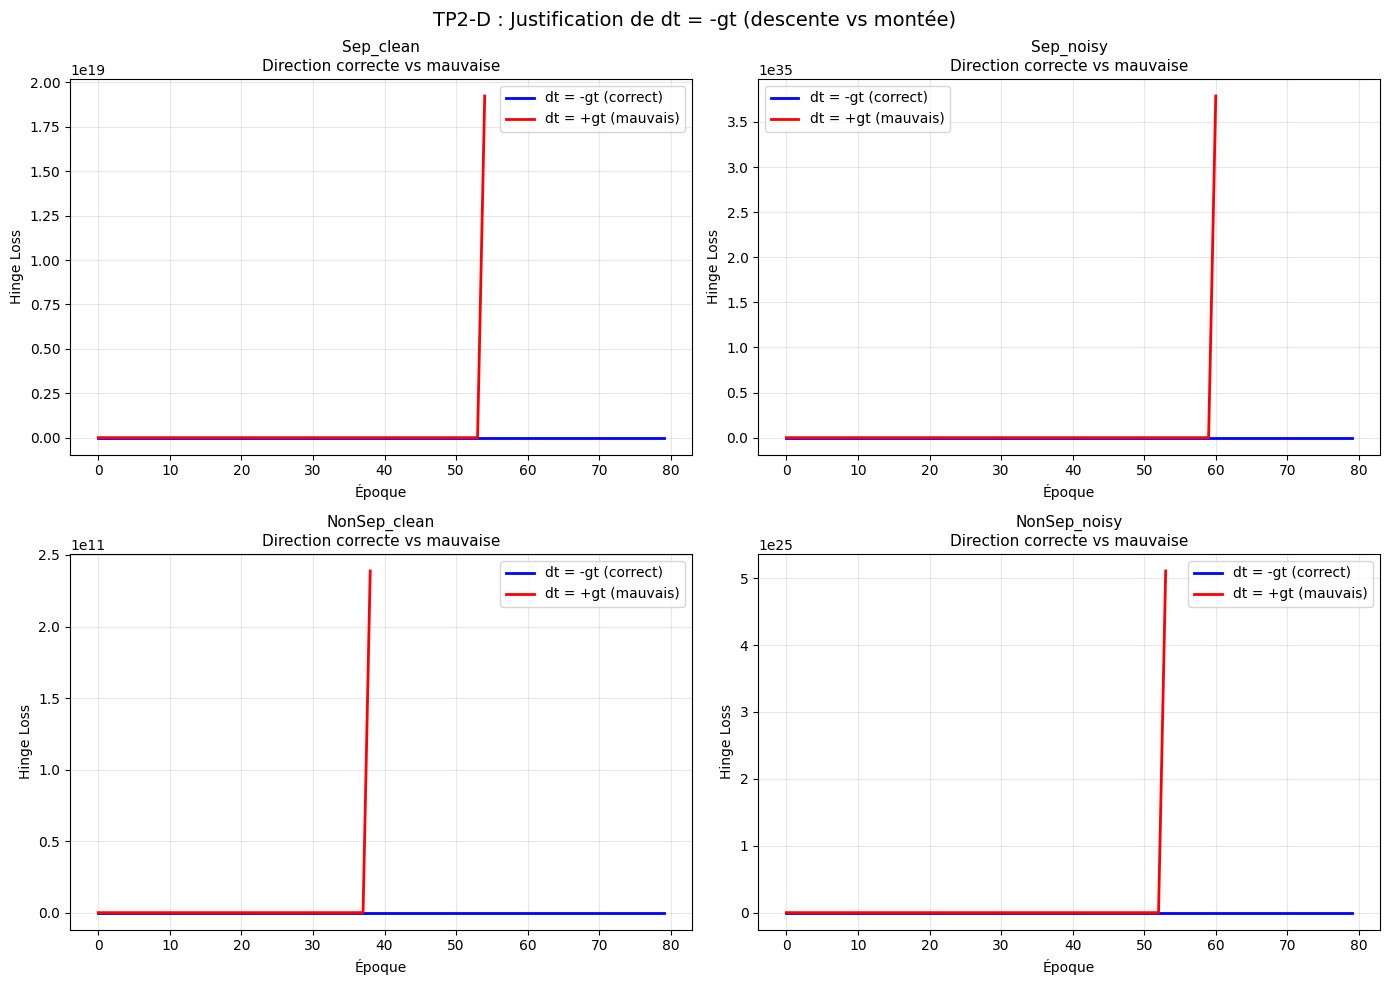

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — CHOIX DE DIRECTION : dt = -gt vs mauvaise direction (TP2-D)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP2-D] Comparaison direction correcte (-g) vs mauvaise direction (+g)")

def train_direction_comparison(X_np, y_np, direction='correct', n_epochs=80):
    """
    Compare :
    - direction correcte : dt = -∂L/∂θ  (descente du sous-gradient)
    - mauvaise direction : dt = +∂L/∂θ  (montée du sous-gradient)
    """
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    y_t = torch.FloatTensor(y_np).to(DEVICE)
    model = CNN1_ResNet50_Adapted(input_dim=2).to(DEVICE)
    lr = 0.01
    losses, accs = [], []

    for epoch in range(n_epochs):
        model.train()
        model.zero_grad()
        scores = model(X_t)
        loss = hinge_loss_manual(scores, y_t)
        loss.backward()

        sign = -1.0 if direction == 'correct' else +1.0
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is not None:
                    p.data += sign * lr * p.grad

        model.eval()
        with torch.no_grad():
            pred = torch.sign(model(X_t))
            acc = (pred == y_t).float().mean().item()
            l = hinge_loss_manual(model(X_t), y_t).item()
        losses.append(l)
        accs.append(acc)

    return losses, accs


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, name in enumerate(names):
    X_np, y_np = datasets[name]
    ax = axes[i // 2, i % 2]
    for direction, color, label in [
        ('correct', 'blue', 'dt = -gt (correct)'),
        ('wrong',   'red',  'dt = +gt (mauvais)')]:
        losses, accs = train_direction_comparison(X_np, y_np, direction=direction)
        ax.plot(losses, color=color, linewidth=2, label=label)
    ax.set_title(f"{name}\nDirection correcte vs mauvaise", fontsize=11)
    ax.set_xlabel("Époque")
    ax.set_ylabel("Hinge Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("TP2-D : Justification de dt = -gt (descente vs montée)", fontsize=14)
plt.tight_layout()
plt.savefig("04_direction_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — ACCÉLÉRATEURS (TP3) : SGD, Momentum, Nesterov, AdaGrad, RMSProp, Adam
# ─────────────────────────────────────────────────────────────────────────────
# Toutes les mises à jour sont implémentées manuellement.

class ManualOptimizer:

    def __init__(self, params, method='sgd', lr=0.01, beta1=0.9, beta2=0.999,
                 eps=1e-8, rho=0.9):
        self.params = list(params)
        self.method = method
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.rho = rho
        self.t = 0

        # États internes
        self.m  = [torch.zeros_like(p) for p in self.params]  # Momentum / 1er moment
        self.v  = [torch.zeros_like(p) for p in self.params]  # 2e moment
        self.G  = [torch.zeros_like(p) for p in self.params]  # Somme des carrés (AdaGrad)
        self.sq = [torch.zeros_like(p) for p in self.params]  # RMSProp

    def step(self, params_next=None):
        """
        Effectue une mise à jour des paramètres selon la méthode choisie.
        """
        self.t += 1
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            g = p.grad.data

            if self.method == 'sgd':
                # θ_{t+1} = θ_t - α * g_t
                p.data -= self.lr * g

            elif self.method == 'momentum':
                # m_{t+1} = β1 * m_t + g_t
                # θ_{t+1} = θ_t - α * m_{t+1}
                self.m[i] = self.beta1 * self.m[i] + g
                p.data -= self.lr * self.m[i]

            elif self.method == 'nesterov':
                # Approx : m_{t+1} = β1*m_t + g_t ; θ -= α*(β1*m_{t+1} + g_t)
                m_prev = self.m[i].clone()
                self.m[i] = self.beta1 * self.m[i] + g
                p.data -= self.lr * (self.beta1 * self.m[i] + g)

            elif self.method == 'adagrad':
                # G_t = G_{t-1} + g_t²
                # θ_{t+1} = θ_t - (α / sqrt(G_t + ε)) * g_t
                self.G[i] += g ** 2
                p.data -= (self.lr / (self.G[i].sqrt() + self.eps)) * g

            elif self.method == 'rmsprop':
                # sq_t = ρ*sq_{t-1} + (1-ρ)*g_t²
                # θ_{t+1} = θ_t - (α / sqrt(sq_t + ε)) * g_t
                self.sq[i] = self.rho * self.sq[i] + (1 - self.rho) * g ** 2
                p.data -= (self.lr / (self.sq[i].sqrt() + self.eps)) * g

            elif self.method == 'adam':
                # m_t = β1*m_{t-1} + (1-β1)*g_t
                # v_t = β2*v_{t-1} + (1-β2)*g_t²
                # m̂_t = m_t / (1 - β1^t) , v̂_t = v_t / (1 - β2^t)
                # θ_{t+1} = θ_t - α * m̂_t / (sqrt(v̂_t) + ε)
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g ** 2
                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)
                p.data -= self.lr * m_hat / (v_hat.sqrt() + self.eps)


In [16]:
def train_with_optimizer(X_np, y_np, model_class, method='sgd', lr=0.01,
                          n_epochs=100, lambda_reg=1e-4):
    """Entraîne un modèle avec un optimiseur manuel."""
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    y_t = torch.FloatTensor(y_np).to(DEVICE)
    model = model_class(input_dim=2).to(DEVICE)
    opt = ManualOptimizer(model.parameters(), method=method, lr=lr)
    losses, accs = [], []

    for _ in range(n_epochs):
        model.train()
        model.zero_grad()
        scores = model(X_t)
        loss = hinge_loss_manual(scores, y_t)
        if lambda_reg > 0:
            l2 = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + lambda_reg / 2.0 * l2
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            pred = torch.sign(model(X_t))
            acc = (pred == y_t).float().mean().item()
        losses.append(loss.item())
        accs.append(acc)

    return losses, accs



In [17]:
# ─── TP3 : Comparaison des 6 accélérateurs × 2 CNN × 4 datasets ──────────────
print("\n[TP3] Comparaison des 6 accélérateurs (CNN1 et CNN2)")
opt_methods = ['sgd', 'momentum', 'nesterov', 'adagrad', 'rmsprop', 'adam']
opt_colors  = {
    'sgd': 'black', 'momentum': 'blue', 'nesterov': 'cyan',
    'adagrad': 'green', 'rmsprop': 'orange', 'adam': 'red'
}

results_opt = {}


[TP3] Comparaison des 6 accélérateurs (CNN1 et CNN2)


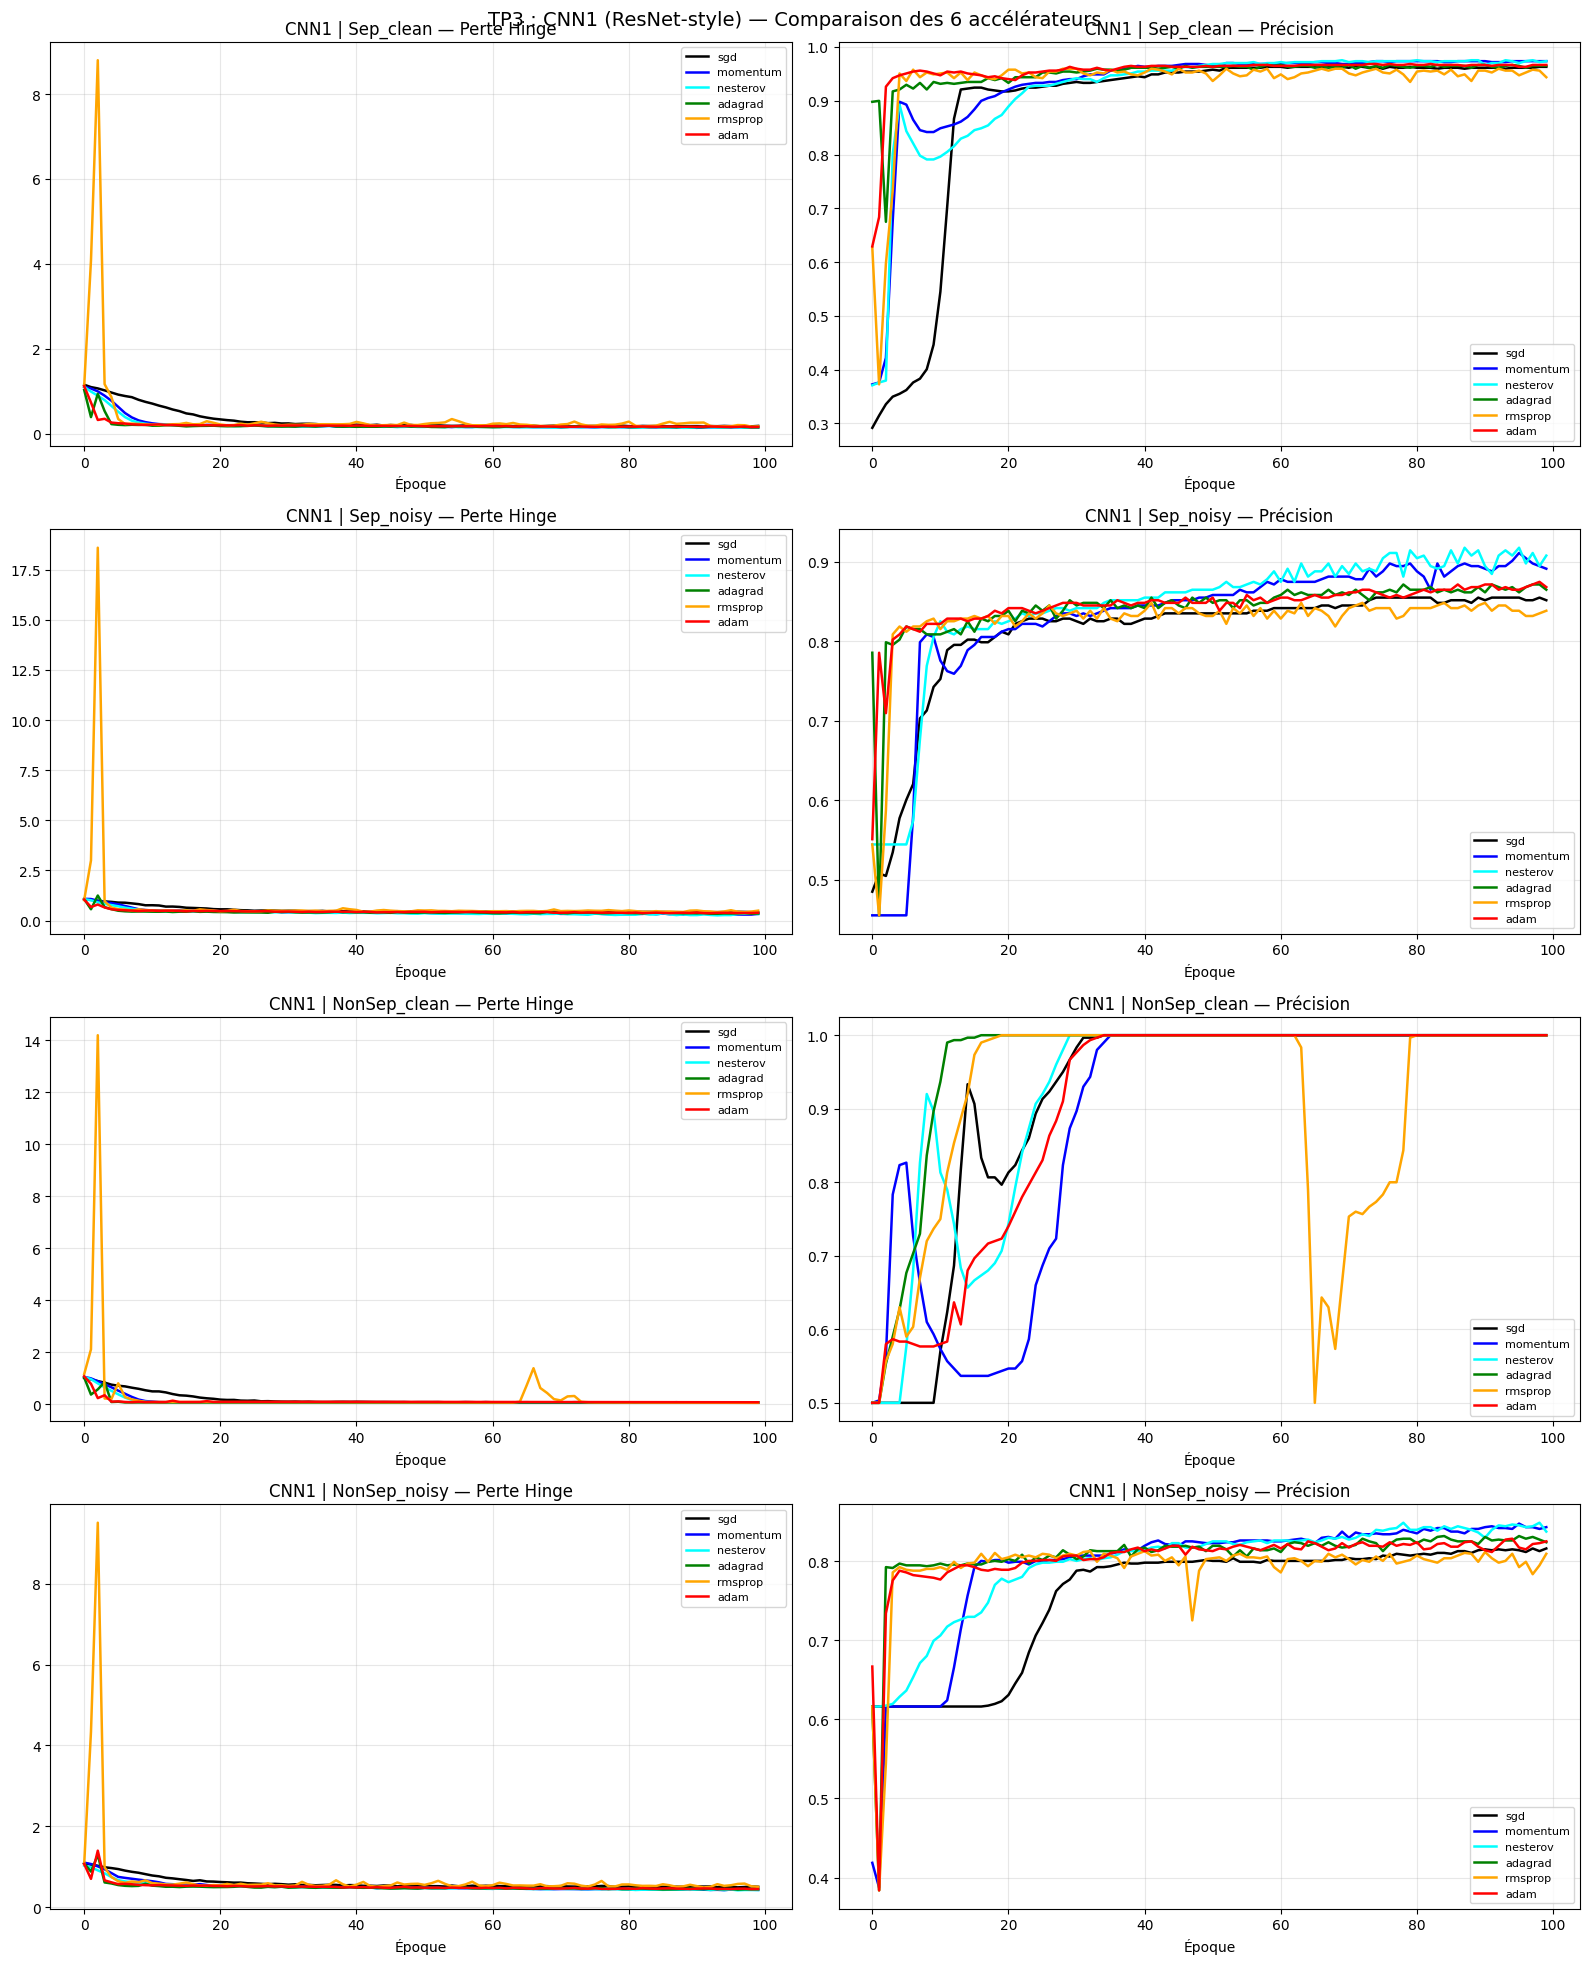

In [18]:
# ── Figure principale : CNN1 ──────────────────────────────────────────────────
fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))
for row, name in enumerate(names):
    X_np, y_np = datasets[name]
    results_opt[name] = {}

    ax_loss = axes[row, 0]
    ax_acc  = axes[row, 1]

    for m in opt_methods:
        losses, accs = train_with_optimizer(
            X_np, y_np, CNN1_ResNet50_Adapted, method=m, n_epochs=100)
        results_opt[name][f'CNN1_{m}'] = (losses, accs)
        ax_loss.plot(losses, color=opt_colors[m], label=m, linewidth=1.8)
        ax_acc.plot(accs,   color=opt_colors[m], label=m, linewidth=1.8)

    ax_loss.set_title(f"CNN1 | {name} — Perte Hinge")
    ax_acc.set_title(f"CNN1 | {name} — Précision")
    for ax in [ax_loss, ax_acc]:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Époque")

plt.suptitle("TP3 : CNN1 (ResNet-style) — Comparaison des 6 accélérateurs", fontsize=14)
plt.tight_layout()
plt.savefig("05_accelerateurs_CNN1.png", dpi=150, bbox_inches='tight')
plt.show()


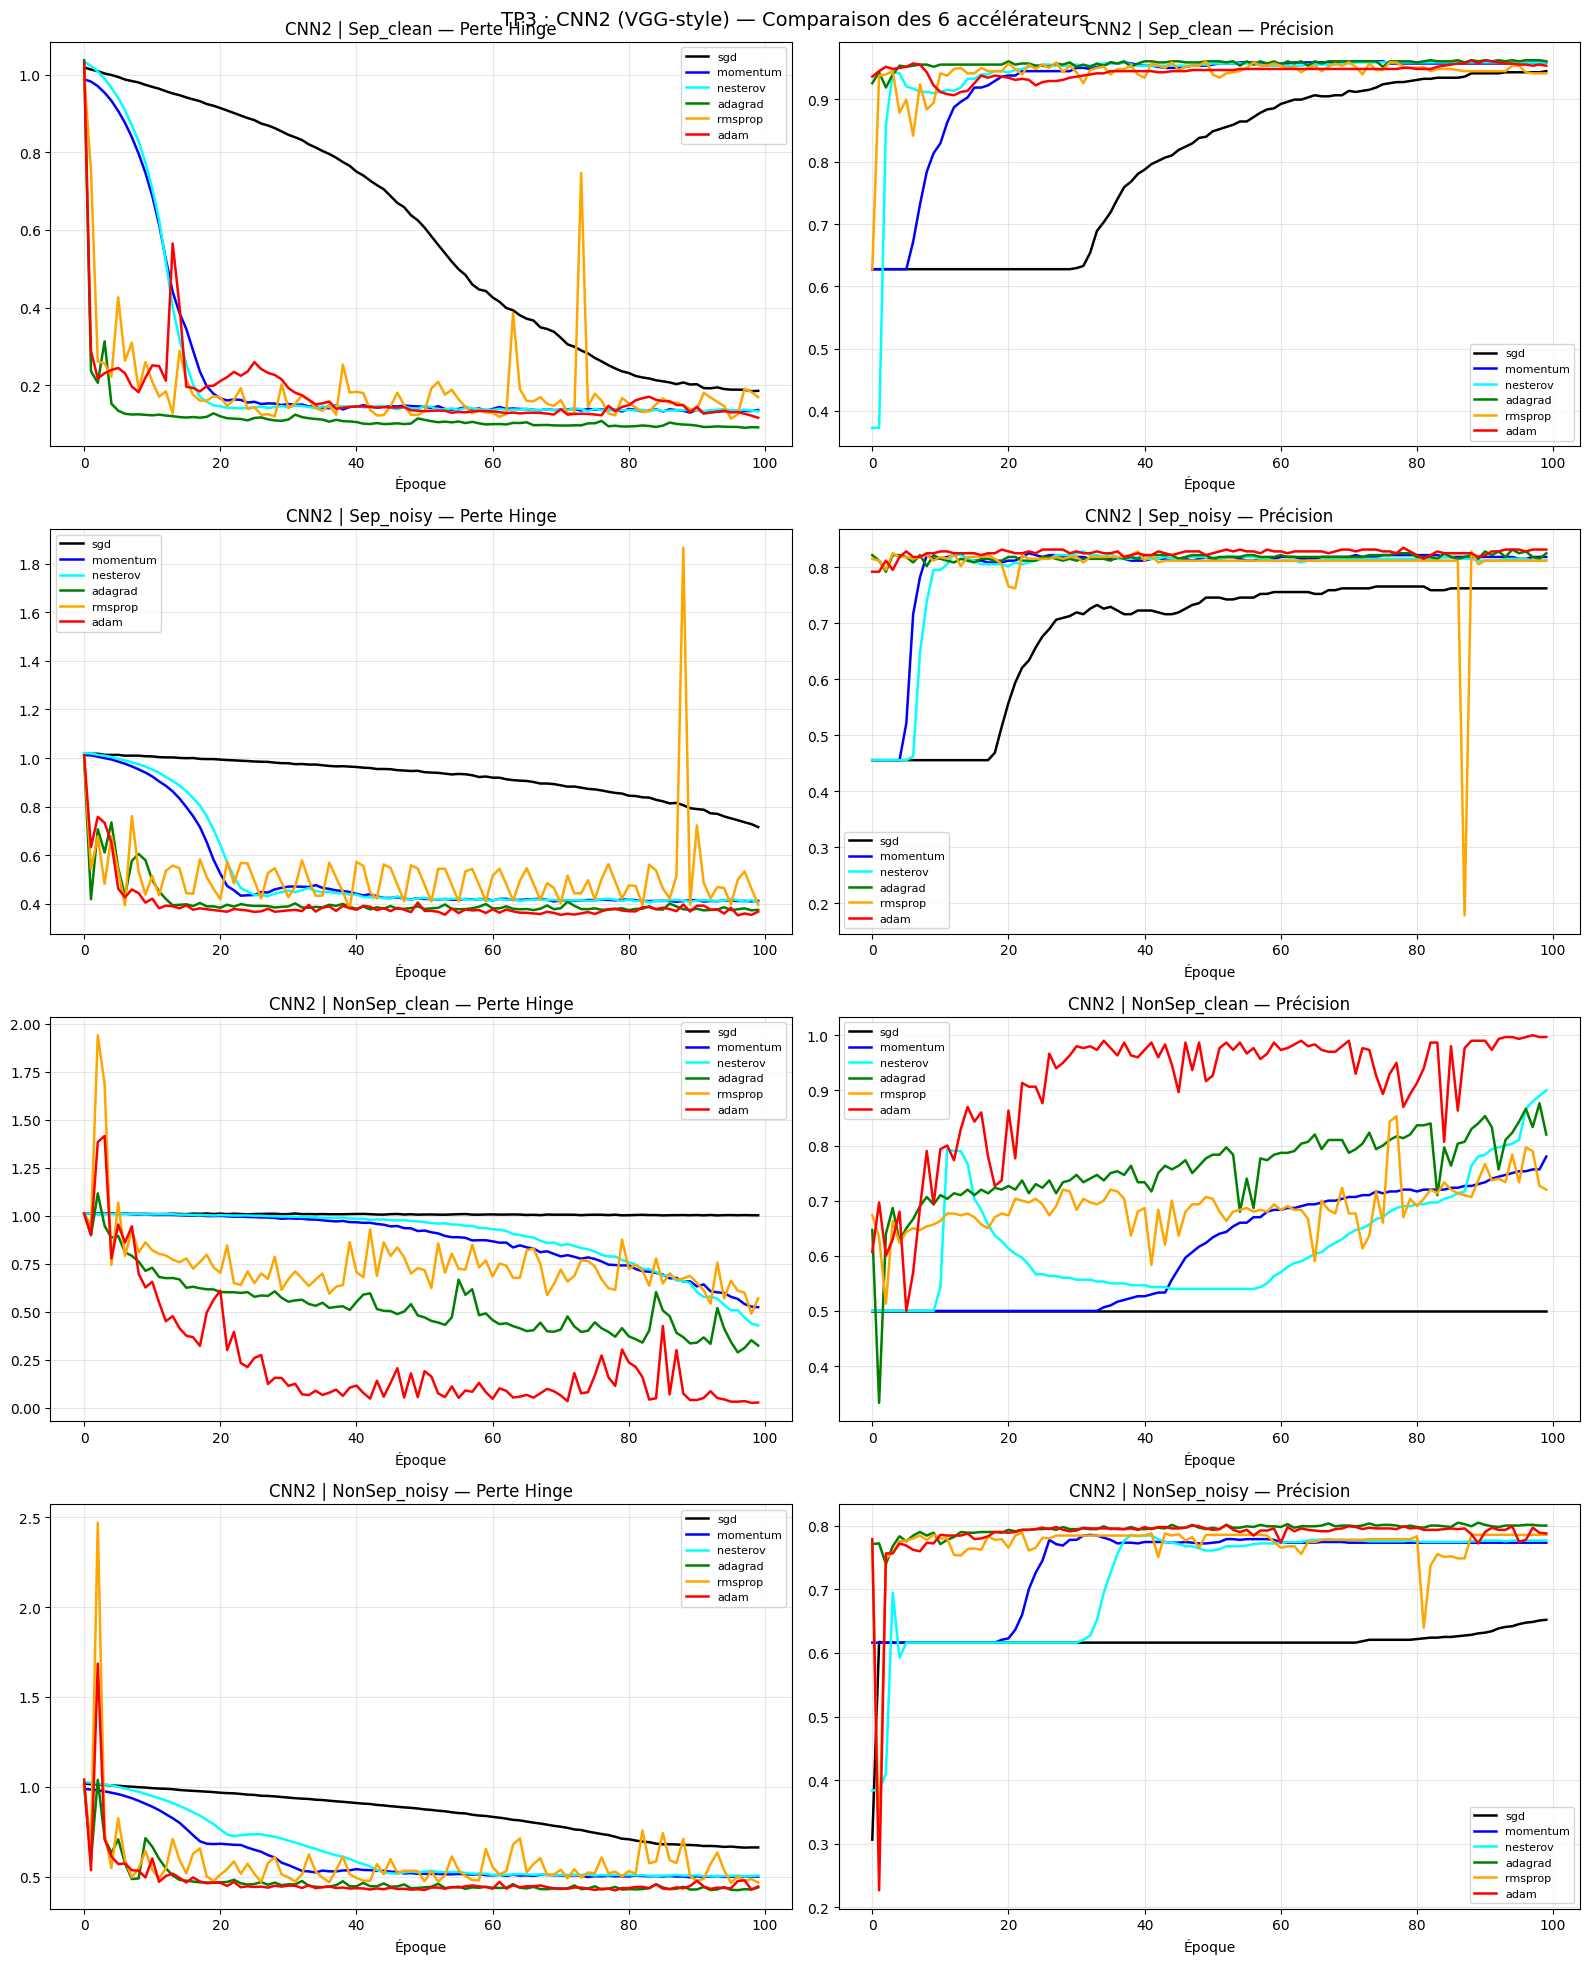

In [19]:
# ── Figure : CNN2 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))
for row, name in enumerate(names):
    X_np, y_np = datasets[name]
    ax_loss = axes[row, 0]
    ax_acc  = axes[row, 1]

    for m in opt_methods:
        losses, accs = train_with_optimizer(
            X_np, y_np, CNN2_VGG19_Adapted, method=m, n_epochs=100)
        results_opt[name][f'CNN2_{m}'] = (losses, accs)
        ax_loss.plot(losses, color=opt_colors[m], label=m, linewidth=1.8)
        ax_acc.plot(accs,   color=opt_colors[m], label=m, linewidth=1.8)

    ax_loss.set_title(f"CNN2 | {name} — Perte Hinge")
    ax_acc.set_title(f"CNN2 | {name} — Précision")
    for ax in [ax_loss, ax_acc]:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Époque")

plt.suptitle("TP3 : CNN2 (VGG-style) — Comparaison des 6 accélérateurs", fontsize=14)
plt.tight_layout()
plt.savefig("06_accelerateurs_CNN2.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── TP3-C : Tableau comparatif global ────────────────────────────────────────
print("\n[TP3-C] Tableau comparatif global CNN1 vs CNN2")
print(f"{'Dataset':<15} {'CNN':<6} {'Méthode':<12} {'Loss↓':<10} {'Acc↑':<10} {'Conv.époque'}")
print("-" * 65)
for name in names:
    for cnn_key, cnn_label in [('CNN1', 'CNN1'), ('CNN2', 'CNN2')]:
        for m in opt_methods:
            losses, accs = results_opt[name][f'{cnn_key}_{m}']
            # Époque de convergence : quand la perte < 1.05 * min
            min_loss = min(losses)
            conv_epoch = next((i for i, l in enumerate(losses)
                               if l <= 1.05 * min_loss), len(losses))
            print(f"{name:<15} {cnn_label:<6} {m:<12} "
                  f"{losses[-1]:.4f}    {accs[-1]*100:.1f}%     {conv_epoch}")
    print()



[TP3-C] Tableau comparatif global CNN1 vs CNN2
Dataset         CNN    Méthode      Loss↓      Acc↑       Conv.époque
-----------------------------------------------------------------
Sep_clean       CNN1   sgd          0.1788    96.3%     67
Sep_clean       CNN1   momentum     0.1442    97.4%     90
Sep_clean       CNN1   nesterov     0.1393    97.4%     69
Sep_clean       CNN1   adagrad      0.1461    96.5%     52
Sep_clean       CNN1   rmsprop      0.1688    94.4%     82
Sep_clean       CNN1   adam         0.1545    96.7%     75
Sep_clean       CNN2   sgd          0.1854    94.6%     91
Sep_clean       CNN2   momentum     0.1360    96.0%     59
Sep_clean       CNN2   nesterov     0.1327    96.0%     46
Sep_clean       CNN2   adagrad      0.0912    96.1%     77
Sep_clean       CNN2   rmsprop      0.1689    94.2%     28
Sep_clean       CNN2   adam         0.1160    95.4%     98

Sep_noisy       CNN1   sgd          0.4047    85.1%     61
Sep_noisy       CNN1   momentum     0.3349    89

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — VALIDATION ET RÉGULARISATION (TP2-VAL / TP5-VAL)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP2-VAL + TP5-VAL] Validation croisée et régularisation L1/L2")

def train_with_reg(X_np, y_np, model_class, lambda_reg=1e-4, reg_type='l2',
                   n_epochs=100, method='adam'):
    """Entraîne avec régularisation L1 ou L2 manuelle."""
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    y_t = torch.FloatTensor(y_np).to(DEVICE)
    model = model_class(input_dim=2).to(DEVICE)
    opt = ManualOptimizer(model.parameters(), method=method, lr=0.005)
    train_losses, val_losses = [], []

    # Split simple train/val
    n = len(X_np)
    idx = np.random.permutation(n)
    n_train = int(0.8 * n)
    idx_train, idx_val = idx[:n_train], idx[n_train:]

    X_tr = X_t[idx_train]; y_tr = y_t[idx_train]
    X_vl = X_t[idx_val];   y_vl = y_t[idx_val]

    for _ in range(n_epochs):
        model.train()
        model.zero_grad()
        scores = model(X_tr)
        loss = hinge_loss_manual(scores, y_tr)

        if lambda_reg > 0:
            if reg_type == 'l2':
                reg = sum(p.pow(2).sum() for p in model.parameters())
            else:  # L1
                reg = sum(p.abs().sum() for p in model.parameters())
            loss = loss + lambda_reg * reg

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = hinge_loss_manual(model(X_vl), y_vl).item()
        train_losses.append(loss.item())
        val_losses.append(val_loss)

    return train_losses, val_losses




[TP2-VAL + TP5-VAL] Validation croisée et régularisation L1/L2


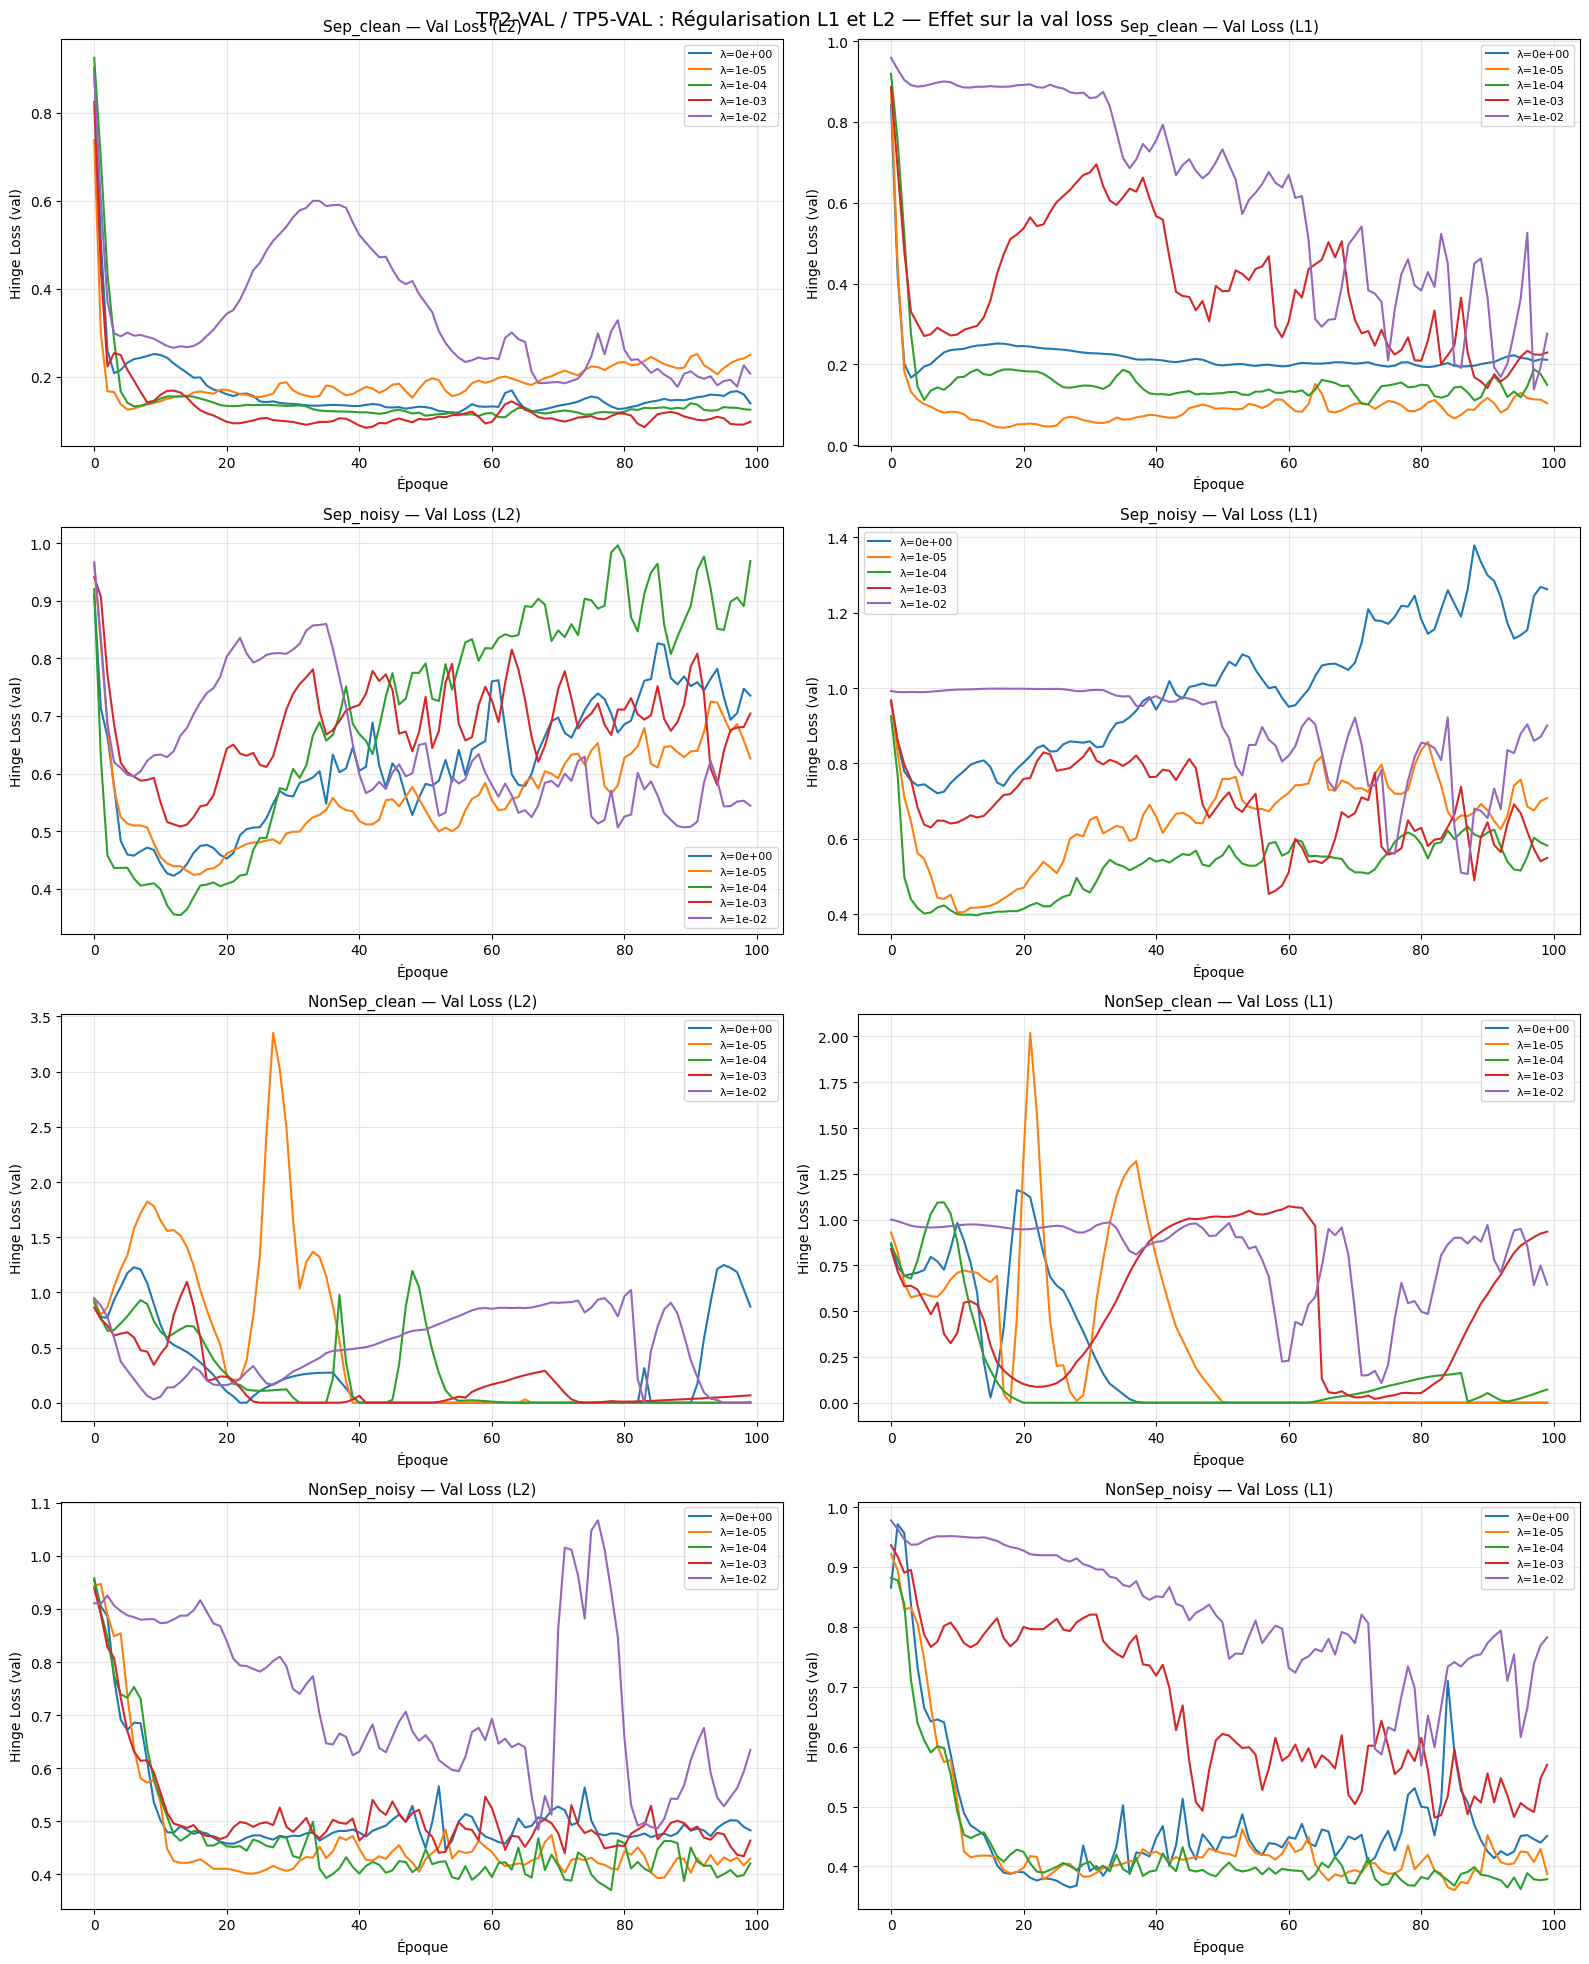

In [22]:
lambdas = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))
for row, name in enumerate(names):
    X_np, y_np = datasets[name]

    # L2
    ax_l2 = axes[row, 0]
    for lam in lambdas:
        tr, vl = train_with_reg(X_np, y_np, CNN1_ResNet50_Adapted,
                                  lambda_reg=lam, reg_type='l2')
        ax_l2.plot(vl, label=f'λ={lam:.0e}', linewidth=1.5)
    ax_l2.set_title(f"{name} — Val Loss (L2)", fontsize=11)
    ax_l2.set_xlabel("Époque")
    ax_l2.set_ylabel("Hinge Loss (val)")
    ax_l2.legend(fontsize=8)
    ax_l2.grid(True, alpha=0.3)

    # L1
    ax_l1 = axes[row, 1]
    for lam in lambdas:
        tr, vl = train_with_reg(X_np, y_np, CNN1_ResNet50_Adapted,
                                  lambda_reg=lam, reg_type='l1')
        ax_l1.plot(vl, label=f'λ={lam:.0e}', linewidth=1.5)
    ax_l1.set_title(f"{name} — Val Loss (L1)", fontsize=11)
    ax_l1.set_xlabel("Époque")
    ax_l1.set_ylabel("Hinge Loss (val)")
    ax_l1.legend(fontsize=8)
    ax_l1.grid(True, alpha=0.3)

plt.suptitle("TP2-VAL / TP5-VAL : Régularisation L1 et L2 — Effet sur la val loss", fontsize=14)
plt.tight_layout()
plt.savefig("07_regularisation_L1_L2.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 — ONLINE LEARNING (TP4-OSD & TP4-SSG)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP4-OSD] Sous-gradient en ligne (Online Subgradient Descent)")

def online_subgradient_descent(X_np, y_np, model_class, lr_type='constant', lr0=0.1, n_epochs=20):
    """
    Version corrigée et stable pour TP4-OSD
    - Gestion correcte du device
    - model.eval() pour éviter l'erreur BatchNorm avec batch=1
    """
    # Conversion vers tenseurs + envoi sur le bon device
    X = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(y_np, dtype=torch.float32).view(-1, 1).to(DEVICE)
    
    N = len(X)
    
    # Création du modèle sur GPU
    model = model_class(input_dim=X.shape[1]).to(DEVICE)
    
    cum_loss = []
    regret = []
    total_loss = 0.0
    
    for epoch in range(n_epochs):
        # Mélange des données
        idx = torch.randperm(N, device=DEVICE)
        X_shuf = X[idx]
        y_shuf = y[idx]
        
        for i in range(N):
            xi = X_shuf[i:i+1]      # shape (1, dim)
            yi = y_shuf[i:i+1]
            
            # IMPORTANT : mode eval pour BatchNorm (évite erreur batch size=1)
            model.eval()
            
            with torch.no_grad():           # pas besoin de gradient pour le forward ici
                score = model(xi)
                loss = hinge_loss_manual(score, yi)
            
            # Calcul du gradient (on repasse en mode train pour backward)
            model.zero_grad()
            loss.backward()
            
            # Mise à jour des poids
            with torch.no_grad():
                lr = lr0 if lr_type == 'constant' else lr0 / ((epoch * N + i + 1)**0.5)
                for p in model.parameters():
                    if p.grad is not None:
                        p.data -= lr * p.grad
            
            total_loss += loss.item()
            cum_loss.append(total_loss)
            regret.append(total_loss / (epoch * N + i + 1))
    
    return cum_loss, regret


[TP4-OSD] Sous-gradient en ligne (Online Subgradient Descent)


In [25]:
# ─── TP4-SSG : Sous-gradient stochastique — comparaison des variantes ────────
print("\n[TP4-SSG] Sous-gradient stochastique : variantes comparées")

def stochastic_subgradient(X_np, y_np, model_class, 
                           batch_type='single', lr_type='constant', 
                           order='random', lr0=0.1, n_epochs=50):
    
    X = torch.tensor(X_np, dtype=torch.float32)
    y = torch.tensor(y_np, dtype=torch.float32).view(-1, 1)
    N = len(X)
    
    model = model_class(input_dim=X.shape[1]).to(DEVICE)
    model.train()
    
    losses = []
    total_loss = 0.0
    count = 0
    
    for epoch in range(n_epochs):
        if order == 'random':
            idx = torch.randperm(N)
        else:
            idx = torch.arange(N)
        
        X_shuf, y_shuf = X[idx], y[idx]
        i = 0
        while i < N:
            if batch_type == 'single':
                bs = 1
            elif batch_type == 'mini':
                bs = 32
            else:  # full
                bs = N
            
            end = min(i + bs, N)
            Xb = X_shuf[i:end]
            yb = y_shuf[i:end]
            
            # Correction BatchNorm
            model.eval()                     # <--- SOLUTION PRINCIPALE
            with torch.no_grad():
                scores = model(Xb)
                loss = hinge_loss_manual(scores, yb)
            
            model.zero_grad()
            loss.backward()
            
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        if lr_type == 'constant':
                            lr = lr0
                        else:
                            lr = lr0 / ((epoch * N + i) ** 0.5 + 1)
                        p.data -= lr * p.grad
            
            total_loss += loss.item() * (end - i)
            count += (end - i)
            losses.append(total_loss / count)
            
            i = end
    
    return losses




[TP4-SSG] Sous-gradient stochastique : variantes comparées


In [26]:
# Définition des 6 variantes TP4-SSG
ssg_variants = [
    ('single', 'constant', 'fixed',  'SSG.1: point+cst+fixe'),
    ('mini',   'constant', 'fixed',  'SSG.2: mini+cst+fixe'),
    ('single', 'constant', 'random', 'SSG.3: point+cst+rand'),
    ('single', 'decreasing','random','SSG.4: point+déc+rand'),
    ('mini',   'constant', 'random', 'SSG.5: mini+cst+rand'),
    ('mini',   'decreasing','random','SSG.6: mini+déc+rand'),
]

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11 — ALGORITHMES DU PREMIER ORDRE (TP5)
# ─────────────────────────────────────────────────────────────────────────────
# Apprentissage supervisé en ligne sur les features extraites par le CNN.

print("\n[TP5] Algorithmes du premier ordre sur features CNN")

def extract_features_cnn(X_np, model):
    """Extrait les features de l'avant-dernière couche du CNN."""
    model.eval()
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    with torch.no_grad():
        # CNN1 : on extrait après le 3e bloc résiduel
        if isinstance(model, CNN1_ResNet50_Adapted):
            x = model.embed(X_t)
            x = F.relu(x + model.res1_main(x))
            x = F.relu(model.res2_skip(x) + model.res2_main(x))
            features = F.relu(model.res3_skip(x) + model.res3_main(x))
        else:
            # CNN2 : features avant la dernière couche
            features = model.net[:-1](X_t)
    return features.cpu().numpy()



[TP5] Algorithmes du premier ordre sur features CNN


In [29]:
# ─── Perceptron, normalized Perceptron, Passive-Aggressive, OSD ──────────────
class OnlineClassifier:
    """
    Classifieur linéaire online opérant sur les features extraites du CNN.
    Implémente : Perceptron, Perceptron normalisé, Passive-Aggressive, OSD.
    """
    def __init__(self, feature_dim, method='perceptron', lr=0.01, C=1.0):
        self.w = np.zeros(feature_dim)
        self.method = method
        self.lr = lr
        self.C = C
        self.t = 0

    def predict(self, x):
        return np.sign(np.dot(self.w, x)) if np.dot(self.w, x) != 0 else 1.0

    def update(self, x, y):
        self.t += 1
        score = np.dot(self.w, x)
        y_hat = np.sign(score) if score != 0 else 1.0

        if self.method == 'perceptron':
            # Mise à jour ssi erreur de classification
            if y_hat != y:
                self.w += self.lr * y * x

        elif self.method == 'normalized_perceptron':
            # Mise à jour normalisée par la norme de x
            if y_hat != y:
                norm_x = np.linalg.norm(x)
                if norm_x > 1e-10:
                    self.w += self.lr * y * x / (norm_x ** 2)

        elif self.method == 'passive_aggressive':
            # PA : mise à jour ssi margin < 1
            margin = y * score
            if margin < 1.0:
                loss = max(0, 1 - margin)
                norm_sq = np.dot(x, x)
                if norm_sq > 1e-10:
                    tau = min(self.C, loss / norm_sq)
                    self.w += tau * y * x

        elif self.method == 'osd':
            # Online Subgradient Descent : sous-gradient de hinge
            margin = y * score
            lr_t = self.lr / np.sqrt(self.t)
            if margin < 1.0:
                self.w += lr_t * y * x
            # Projection optionnelle : ||w|| ≤ 1/√λ
            norm_w = np.linalg.norm(self.w)
            if norm_w > 1.0:
                self.w /= norm_w


In [30]:
def run_online_classifier(X_features, y_np, method='perceptron',
                           n_passes=5, lr=0.01, C=1.0):
    """Entraîne le classifieur online et retourne les métriques."""
    n, d = X_features.shape
    clf = OnlineClassifier(d, method=method, lr=lr, C=C)
    cum_losses, mistakes, accs = [], [], []
    total_mistakes = 0
    t = 0

    for _ in range(n_passes):
        perm = np.random.permutation(n)
        for idx in perm:
            t += 1
            x, y = X_features[idx], y_np[idx]
            y_hat = clf.predict(x)
            loss = max(0, 1 - y * np.dot(clf.w, x))
            cum_losses.append(loss)
            if y_hat != y:
                total_mistakes += 1
            mistakes.append(total_mistakes)
            clf.update(x, y)

        # Précision sur tout le dataset
        preds = np.array([clf.predict(X_features[i]) for i in range(n)])
        accs.append((preds == y_np).mean())

    return cum_losses, mistakes, accs, clf


In [31]:
# Entraîner CNN1 pré-entraîné pour extraire les features
print("  Pré-entraînement CNN1 pour extraction de features...")
pretrained_cnn1 = {}
for name, (X_np, y_np) in datasets.items():
    losses_pt, _ = train_with_optimizer(
        X_np, y_np, CNN1_ResNet50_Adapted, method='adam', n_epochs=80)
    model_pt = CNN1_ResNet50_Adapted(input_dim=2).to(DEVICE)
    # Re-entraîner pour garder le modèle
    X_t = torch.FloatTensor(X_np).to(DEVICE)
    y_t = torch.FloatTensor(y_np).to(DEVICE)
    opt = ManualOptimizer(model_pt.parameters(), method='adam', lr=0.005)
    for _ in range(80):
        model_pt.zero_grad()
        scores = model_pt(X_t)
        loss = hinge_loss_manual(scores, y_t)
        loss.backward()
        opt.step()
    pretrained_cnn1[name] = model_pt


  Pré-entraînement CNN1 pour extraction de features...


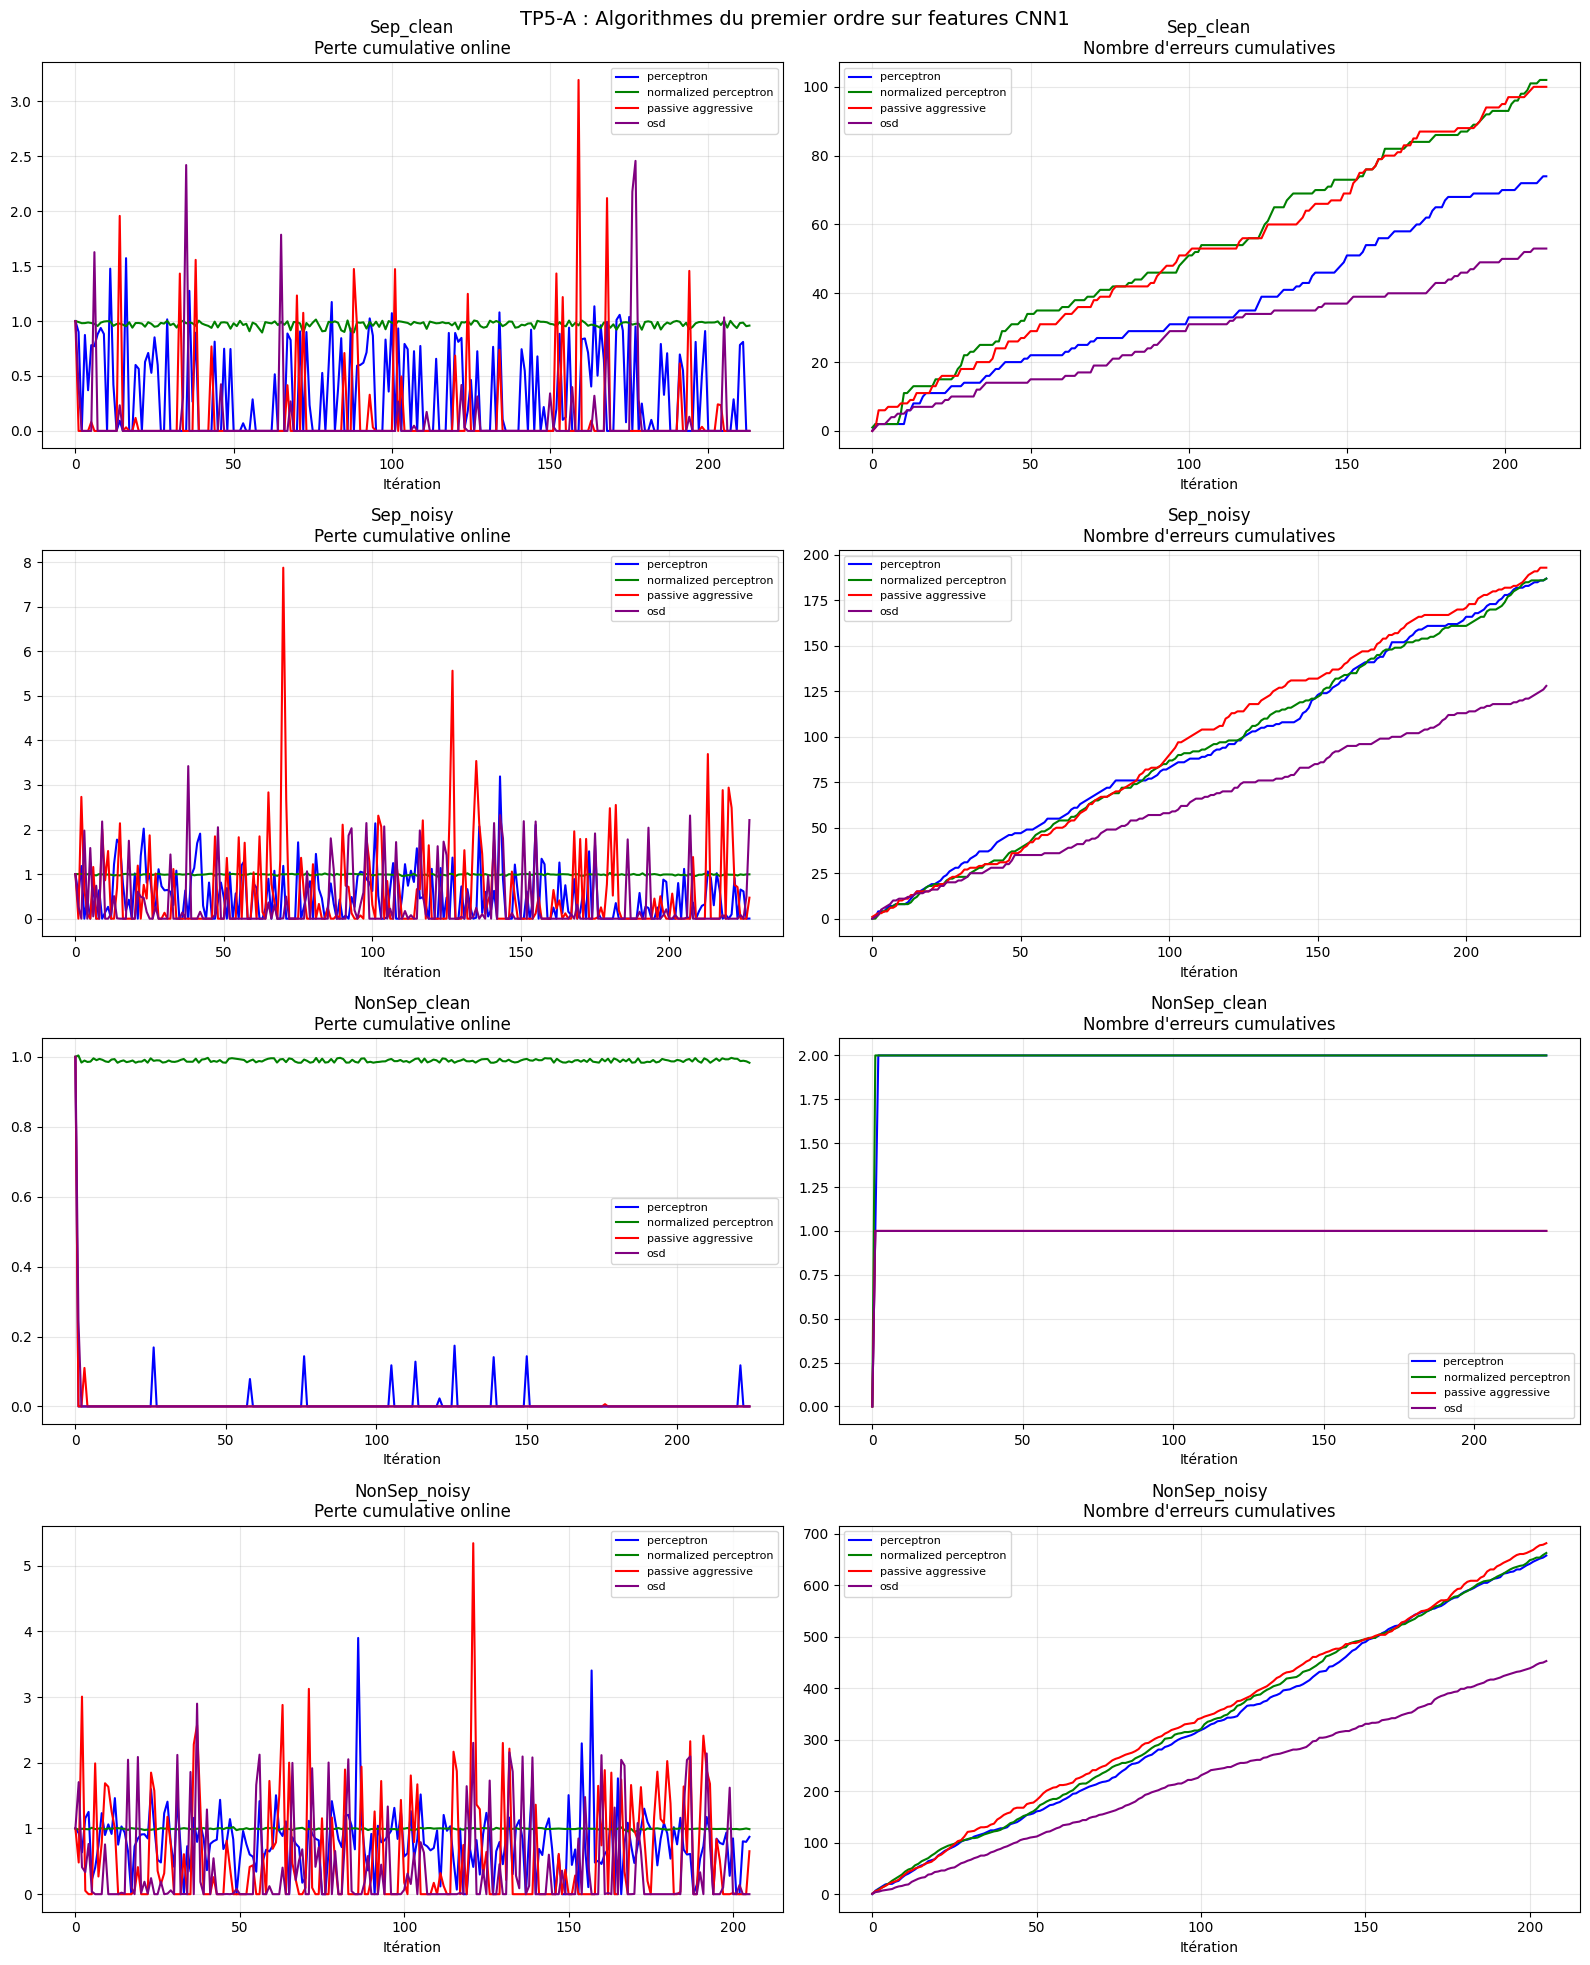

In [32]:
# ─── Figure TP5 : comparaison des 4 algorithmes online ───────────────────────
online_methods = ['perceptron', 'normalized_perceptron', 'passive_aggressive', 'osd']
online_colors  = {'perceptron': 'blue', 'normalized_perceptron': 'green',
                  'passive_aggressive': 'red', 'osd': 'purple'}

fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))
for row, name in enumerate(names):
    X_np, y_np = datasets[name]
    features = extract_features_cnn(X_np, pretrained_cnn1[name])

    ax_loss = axes[row, 0]
    ax_err  = axes[row, 1]

    for m in online_methods:
        cum_losses, mistakes, accs, _ = run_online_classifier(
            features, y_np, method=m, n_passes=3)
        # Sous-échantillonner pour la lisibilité
        step = max(1, len(cum_losses) // 200)
        ax_loss.plot(cum_losses[::step], color=online_colors[m],
                     label=m.replace('_', ' '), linewidth=1.5)
        ax_err.plot(mistakes[::step],   color=online_colors[m],
                    label=m.replace('_', ' '), linewidth=1.5)

    ax_loss.set_title(f"{name}\nPerte cumulative online")
    ax_err.set_title(f"{name}\nNombre d'erreurs cumulatives")
    for ax in [ax_loss, ax_err]:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Itération")

plt.suptitle("TP5-A : Algorithmes du premier ordre sur features CNN1", fontsize=14)
plt.tight_layout()
plt.savefig("10_online_algorithms_TP5.png", dpi=150, bbox_inches='tight')
plt.show()



[TP5-H] Prediction with Expert Advice — Hedge Algorithm
  Sep_clean: Perte sys=113.0, Meilleur expert=105.0, Regret=8.0
  Sep_noisy: Perte sys=43.0, Meilleur expert=42.0, Regret=1.0
  NonSep_clean: Perte sys=1.0, Meilleur expert=0.0, Regret=1.0
  NonSep_noisy: Perte sys=119.0, Meilleur expert=109.0, Regret=10.0


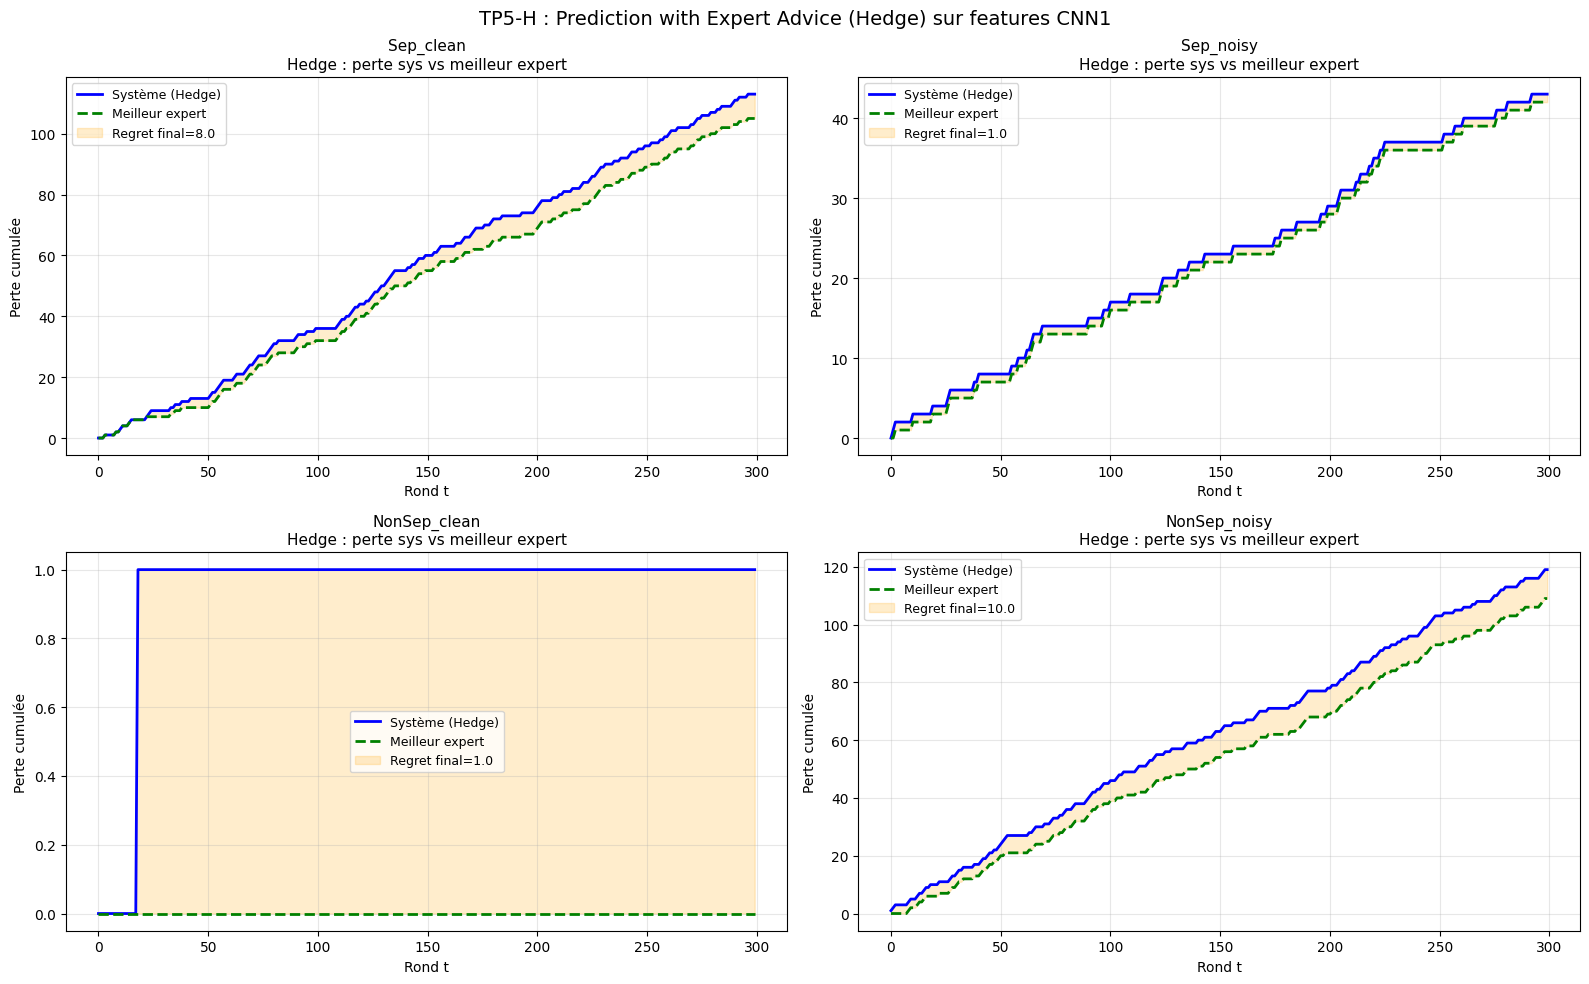

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 — PREDICTION WITH EXPERT ADVICE (TP5-H)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP5-H] Prediction with Expert Advice — Hedge Algorithm")

def expert_advice_scenario(X_np, y_np, n_experts=5, n_rounds=200, eta=0.5):
    """
    TP5-H : Scénario Prediction with Expert Advice.
    Experts : classifieurs linéaires avec différentes initialisations aléatoires.
    Algorithme Hedge : poids proportionnels à exp(-η * perte_cumulée).
    Retourne : perte_systeme, pertes_experts, regret
    """
    n, d_feat = X_np.shape
    # Experts : poids linéaires aléatoires
    np.random.seed(0)
    expert_weights = [np.random.randn(d_feat) * 0.1 for _ in range(n_experts)]
    hedge_weights = np.ones(n_experts) / n_experts  # Poids Hedge uniformes
    expert_cum_losses = np.zeros(n_experts)
    system_cum_loss = 0.0

    system_losses, best_expert_losses, regrets = [], [], []
    idx_list = np.random.choice(n, n_rounds, replace=True)

    for t, idx in enumerate(idx_list):
        x, y = X_np[idx], y_np[idx]

        # Prédictions de chaque expert
        expert_preds = np.array([np.sign(np.dot(ew, x)) if np.dot(ew, x) != 0 else 1.0
                                  for ew in expert_weights])

        # Pertes individuelles des experts (0/1 loss)
        expert_instant_losses = (expert_preds != y).astype(float)

        # Prédiction du système : vote pondéré par les poids Hedge
        weighted_vote = sum(hedge_weights[i] * expert_preds[i]
                            for i in range(n_experts))
        system_pred = np.sign(weighted_vote) if weighted_vote != 0 else 1.0
        system_loss = float(system_pred != y)

        # Mise à jour des pertes cumulatives
        expert_cum_losses += expert_instant_losses
        system_cum_loss += system_loss

        # Mise à jour des poids Hedge : w_i ← w_i * exp(-η * ℓ_i)
        hedge_weights *= np.exp(-eta * expert_instant_losses)
        hedge_weights /= hedge_weights.sum()

        # Meilleur expert a posteriori
        best_expert_loss = expert_cum_losses.min()

        system_losses.append(system_cum_loss)
        best_expert_losses.append(best_expert_loss)
        regrets.append(system_cum_loss - best_expert_loss)

    return system_losses, best_expert_losses, regrets, expert_cum_losses


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, name in enumerate(names):
    X_np, y_np = datasets[name]
    features = extract_features_cnn(X_np, pretrained_cnn1[name])

    sys_loss, best_loss, regret, final_exp_losses = expert_advice_scenario(
        features, y_np, n_experts=5, n_rounds=300, eta=0.5)

    ax = axes[i // 2, i % 2]
    T = len(sys_loss)
    ax.plot(sys_loss,  'b-', linewidth=2, label='Système (Hedge)')
    ax.plot(best_loss, 'g--', linewidth=2, label='Meilleur expert')
    ax.fill_between(range(T), best_loss, sys_loss, alpha=0.2, color='orange',
                    label=f'Regret final={regret[-1]:.1f}')
    ax.set_title(f"{name}\nHedge : perte sys vs meilleur expert", fontsize=11)
    ax.set_xlabel("Rond t")
    ax.set_ylabel("Perte cumulée")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"  {name}: Perte sys={sys_loss[-1]:.1f}, "
          f"Meilleur expert={best_loss[-1]:.1f}, Regret={regret[-1]:.1f}")

plt.suptitle("TP5-H : Prediction with Expert Advice (Hedge) sur features CNN1", fontsize=14)
plt.tight_layout()
plt.savefig("11_expert_advice.png", dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13 — NOYAUX (TP5-K) : Perceptron kernelisé
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP5-K] Perceptron kernelisé (noyaux RBF, Polynomial, Linéaire)")

def rbf_kernel(x1, x2, gamma=1.0):
    """K(x, x') = exp(-γ ||x - x'||²)"""
    diff = x1 - x2
    return np.exp(-gamma * np.dot(diff, diff))

def poly_kernel(x1, x2, degree=3, c=1.0):
    """K(x, x') = (x·x' + c)^d"""
    return (np.dot(x1, x2) + c) ** degree

def linear_kernel(x1, x2):
    """K(x, x') = x·x'"""
    return np.dot(x1, x2)

KERNELS = {
    'RBF (γ=1)':   lambda x1, x2: rbf_kernel(x1, x2, gamma=1.0),
    'RBF (γ=0.1)': lambda x1, x2: rbf_kernel(x1, x2, gamma=0.1),
    'Polynomial':  lambda x1, x2: poly_kernel(x1, x2, degree=3),
    'Linéaire':    linear_kernel,
}



[TP5-K] Perceptron kernelisé (noyaux RBF, Polynomial, Linéaire)


In [35]:
def kernelized_perceptron(X_np, y_np, kernel_fn, n_passes=2, max_sv=200):
    """
    Perceptron kernelisé : f(x) = Σ α_i y_i K(x_i, x)
    Mise à jour : si y_i * f(x_i) ≤ 0 → α_i += 1
    """
    n = len(X_np)
    alphas = np.zeros(n)
    sv_idx = []  # Indices des vecteurs support
    errors = []
    total_err = 0

    for _ in range(n_passes):
        for i in range(n):
            xi, yi = X_np[i], y_np[i]
            # Score kernelisé
            score = sum(alphas[j] * y_np[j] * kernel_fn(X_np[j], xi)
                        for j in sv_idx) if sv_idx else 0.0
            if yi * score <= 0:
                alphas[i] += 1
                if i not in sv_idx:
                    sv_idx.append(i)
                total_err += 1
            errors.append(total_err)

    return errors, alphas, sv_idx


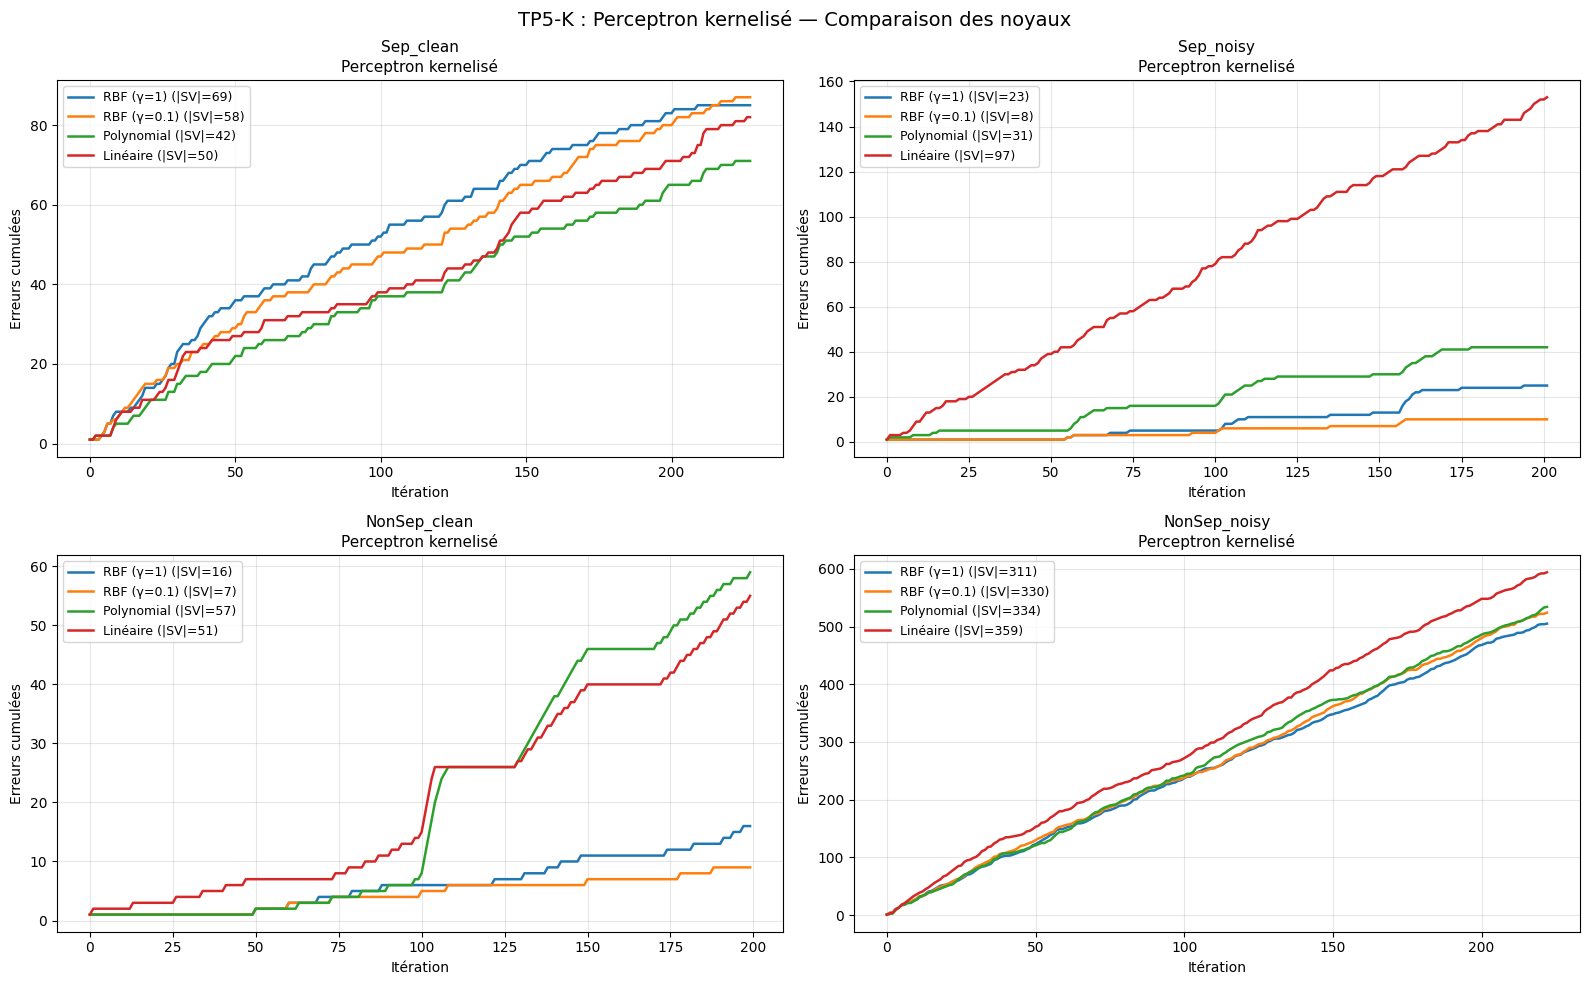

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, name in enumerate(names):
    X_np, y_np = datasets[name]
    ax = axes[i // 2, i % 2]

    for k_name, k_fn in KERNELS.items():
        errors, alphas, sv_idx = kernelized_perceptron(
            X_np, y_np, k_fn, n_passes=2)
        step = max(1, len(errors) // 200)
        ax.plot(errors[::step], label=f'{k_name} (|SV|={len(sv_idx)})',
                linewidth=1.8)

    ax.set_title(f"{name}\nPerceptron kernelisé", fontsize=11)
    ax.set_xlabel("Itération")
    ax.set_ylabel("Erreurs cumulées")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("TP5-K : Perceptron kernelisé — Comparaison des noyaux", fontsize=14)
plt.tight_layout()
plt.savefig("12_kernelized_perceptron.png", dpi=150, bbox_inches='tight')
plt.show()


[TP5-ND] Normes usuelles et normes duales

RAPPEL THÉORIQUE :
──────────────────
• Norme L1 : ||w||₁ = Σ|wᵢ|      → duale : L∞ (||w||∞ = max|wᵢ|)
• Norme L2 : ||w||₂ = √(Σwᵢ²)    → duale : L2 (auto-duale)
• Norme Lp : ||w||_p = (Σ|wᵢ|^p)^(1/p)  → duale : Lq avec 1/p + 1/q = 1

RÔLE DANS LA RÉGULARISATION :
──────────────────────────────
• L2 (Tikhonov) : pénalise ||θ||₂², favorise les petits poids diffus
  → Ridge Regression, weight decay
• L1 (Lasso)    : pénalise ||θ||₁, favorise la sparsité (poids = 0)
  → Sélection automatique de features

LIEN AVEC LES BORNES DE REGRET (Online Learning) :
────────────────────────────────────────────────────
• OGD avec L2 : Regret ≤ ||u*||₂ * √T * (diam/η + η * L²)
• Hedge (experts) : Regret ≤ √(T * ln(N) / 2) où N = nb experts
• Pour PAC/Oracle : regret = O(√(||u*||² * T)) en général



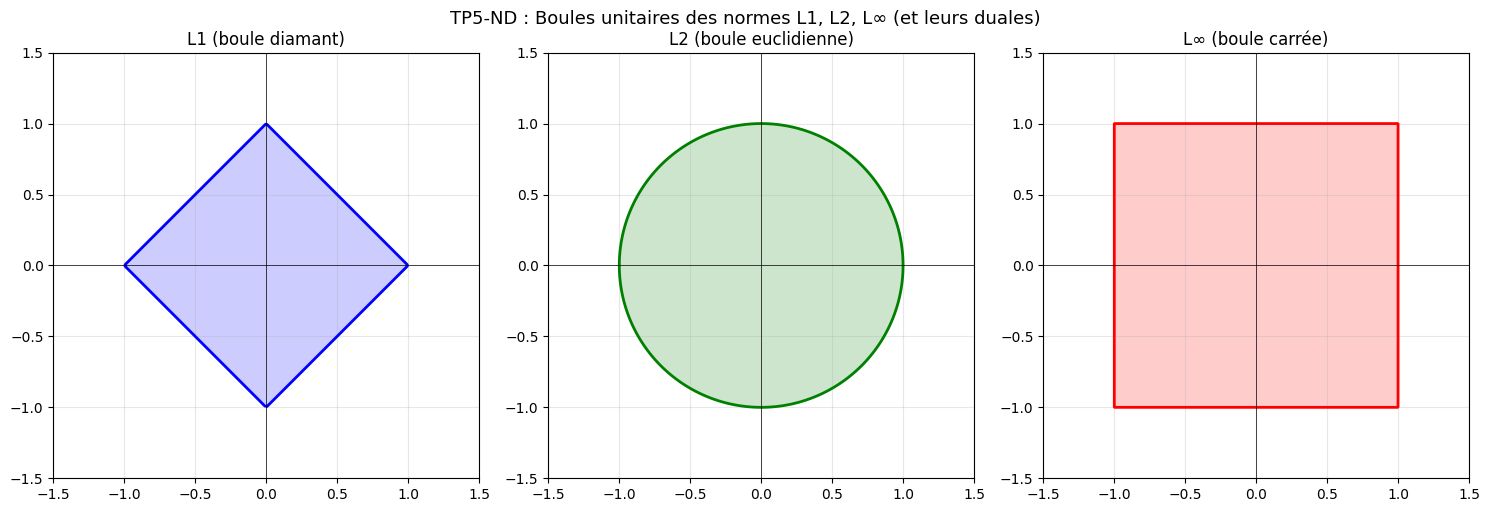

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14 — NORMES ET NORMES DUALES (TP5-ND)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP5-ND] Normes usuelles et normes duales")
print("=" * 60)
print("""
RAPPEL THÉORIQUE :
──────────────────
• Norme L1 : ||w||₁ = Σ|wᵢ|      → duale : L∞ (||w||∞ = max|wᵢ|)
• Norme L2 : ||w||₂ = √(Σwᵢ²)    → duale : L2 (auto-duale)
• Norme Lp : ||w||_p = (Σ|wᵢ|^p)^(1/p)  → duale : Lq avec 1/p + 1/q = 1

RÔLE DANS LA RÉGULARISATION :
──────────────────────────────
• L2 (Tikhonov) : pénalise ||θ||₂², favorise les petits poids diffus
  → Ridge Regression, weight decay
• L1 (Lasso)    : pénalise ||θ||₁, favorise la sparsité (poids = 0)
  → Sélection automatique de features

LIEN AVEC LES BORNES DE REGRET (Online Learning) :
────────────────────────────────────────────────────
• OGD avec L2 : Regret ≤ ||u*||₂ * √T * (diam/η + η * L²)
• Hedge (experts) : Regret ≤ √(T * ln(N) / 2) où N = nb experts
• Pour PAC/Oracle : regret = O(√(||u*||² * T)) en général
""")

# Visualisation des boules unitaires
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
theta = np.linspace(0, 2 * np.pi, 300)

norms_info = [
    ('L1 (boule diamant)',   lambda x, y: np.abs(x) + np.abs(y),    'blue'),
    ('L2 (boule euclidienne)',lambda x, y: np.sqrt(x**2 + y**2),    'green'),
    ('L∞ (boule carrée)',    lambda x, y: np.maximum(np.abs(x), np.abs(y)), 'red'),
]

for ax, (name_norm, norm_fn, color) in zip(axes, norms_info):
    # Contour : niveau 1
    x_grid = np.linspace(-1.5, 1.5, 300)
    y_grid = np.linspace(-1.5, 1.5, 300)
    X_g, Y_g = np.meshgrid(x_grid, y_grid)
    Z = norm_fn(X_g, Y_g)
    ax.contour(X_g, Y_g, Z, levels=[1.0], colors=[color], linewidths=2)
    ax.contourf(X_g, Y_g, Z, levels=[0, 1.0], colors=[color], alpha=0.2)
    ax.set_title(name_norm, fontsize=12)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.grid(True, alpha=0.3)

plt.suptitle("TP5-ND : Boules unitaires des normes L1, L2, L∞ (et leurs duales)", fontsize=13)
plt.tight_layout()
plt.savefig("13_normes_duales.png", dpi=150, bbox_inches='tight')
plt.show()


[TP5-REG] Régularisation en ligne L1, L2 — effet de λ


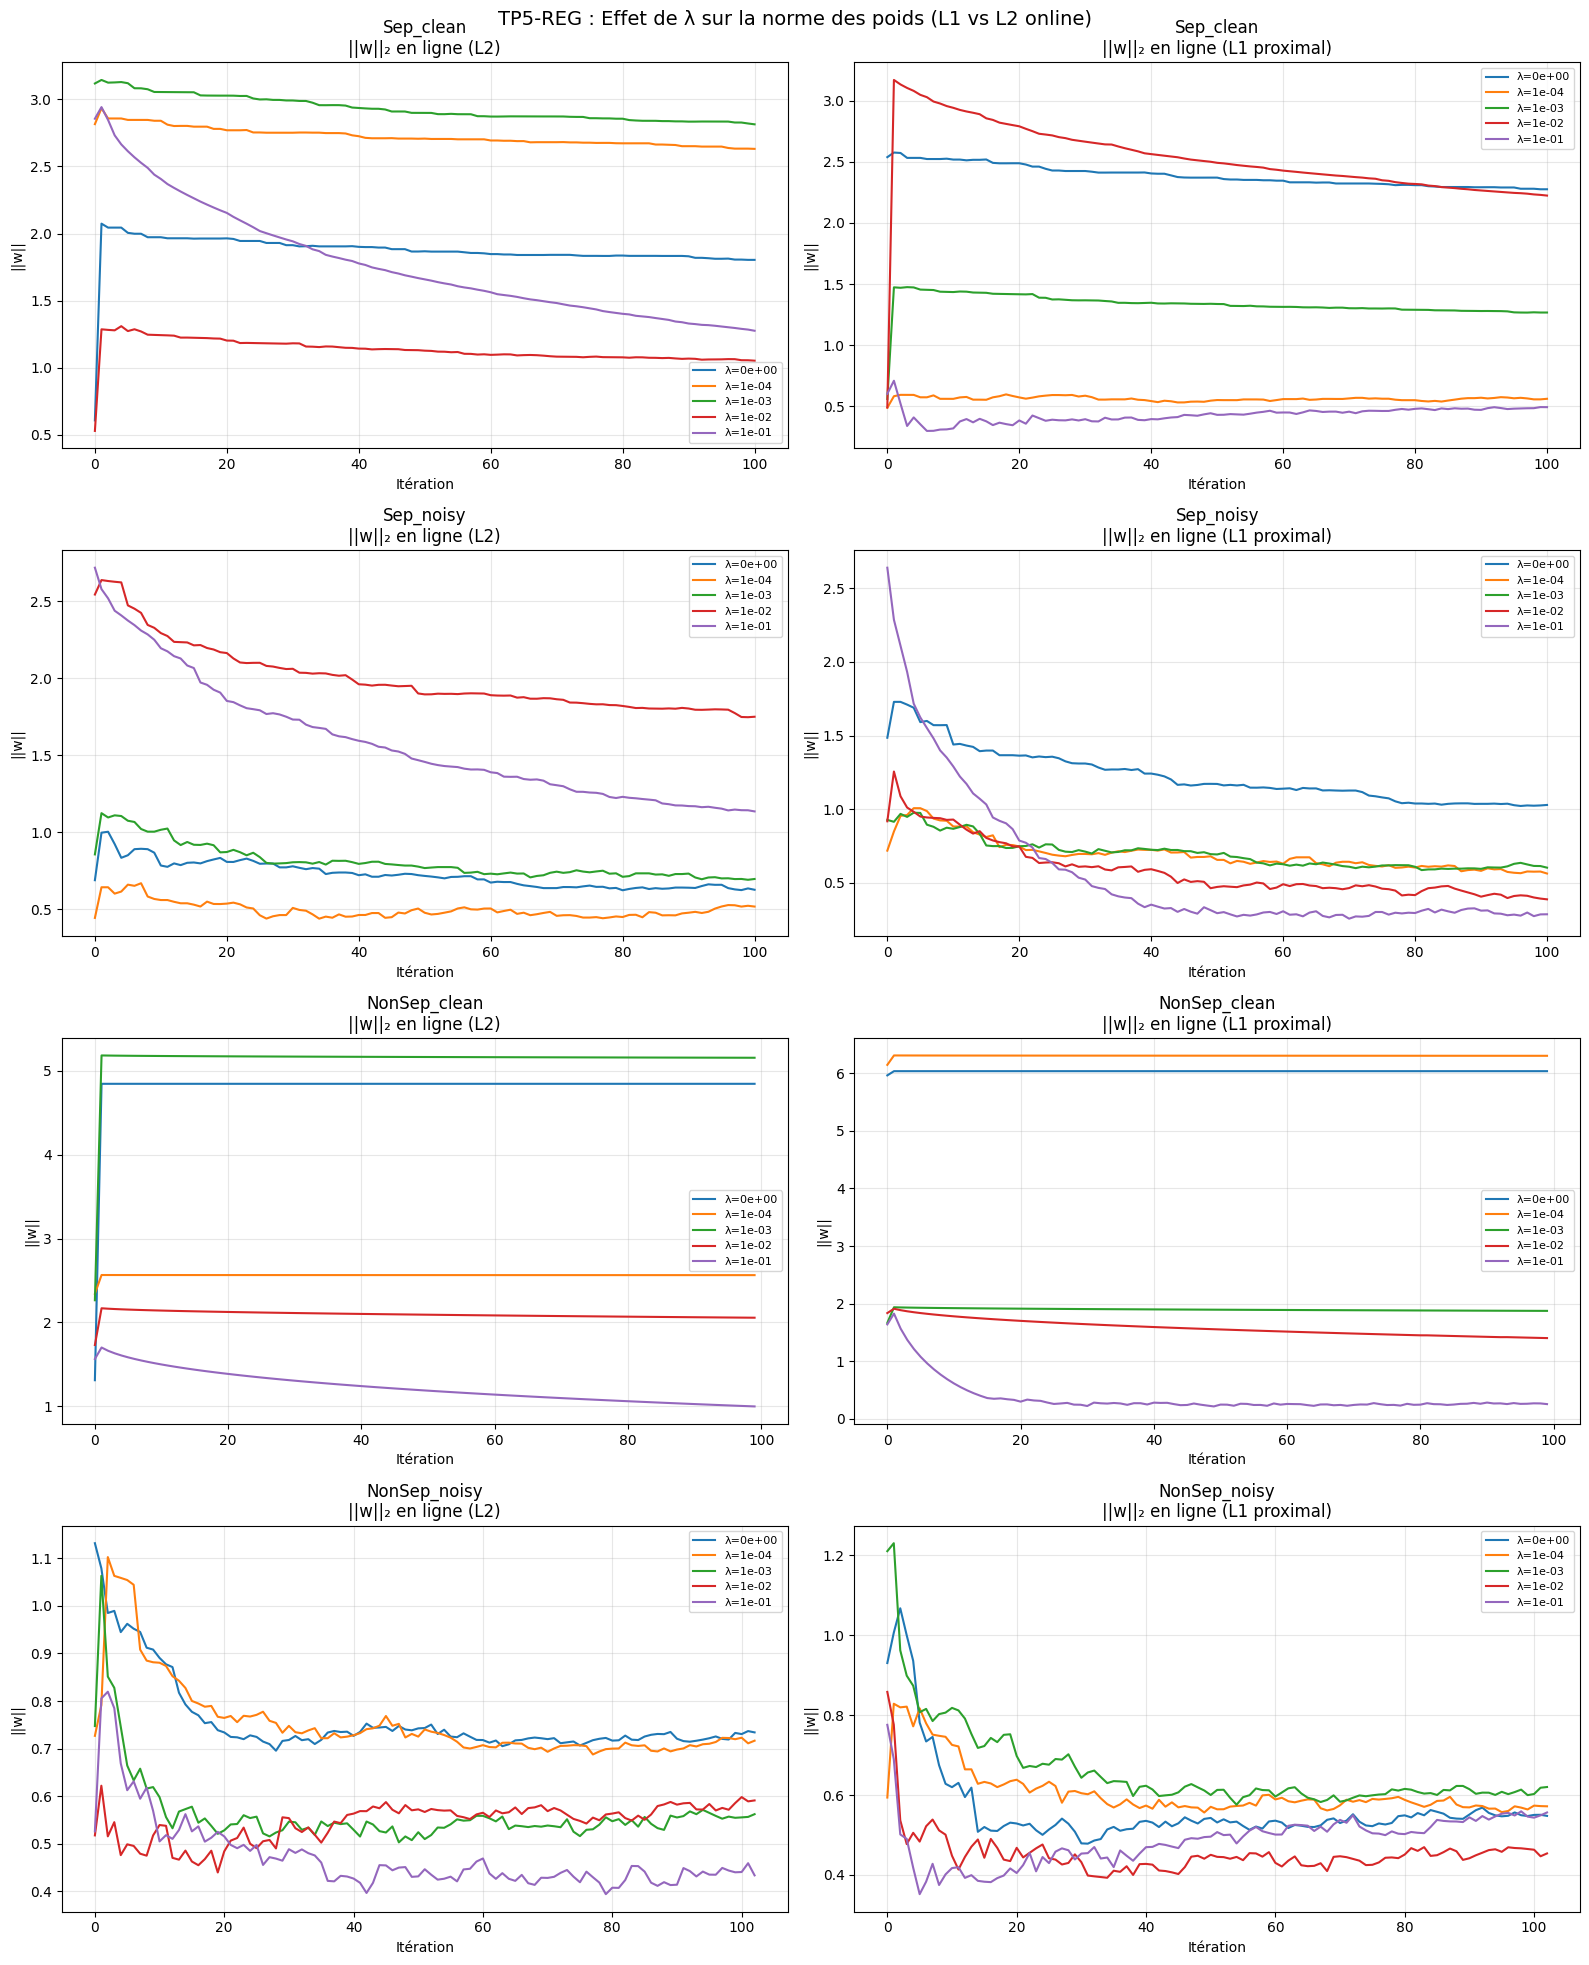

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15 — RÉGULARISATION EN LIGNE (TP5-REG)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[TP5-REG] Régularisation en ligne L1, L2 — effet de λ")

def online_regularized(X_features, y_np, reg_type='l2', lambda_reg=0.01,
                        n_passes=3, lr0=0.1):
    """
    Sous-gradient en ligne avec régularisation L1 ou L2.
    Mise à jour :
    - L2 : w ← w - α*(g + λ*w)       (gradient de la perte + λ||w||²)
    - L1 : w ← soft_threshold(w - α*g, α*λ)  (opérateur proximal L1)
    """
    n, d = X_features.shape
    w = np.zeros(d)
    cum_losses, norms_w = [], []
    t = 0

    for _ in range(n_passes):
        perm = np.random.permutation(n)
        for idx in perm:
            t += 1
            x, y = X_features[idx], y_np[idx]
            lr = lr0 / np.sqrt(t)
            score = np.dot(w, x)
            loss = max(0, 1 - y * score)

            # Sous-gradient de hinge
            g = -y * x if y * score < 1 else np.zeros(d)

            if reg_type == 'l2':
                w = w - lr * (g + lambda_reg * w)
            else:  # L1 : opérateur proximal (soft-thresholding)
                w = w - lr * g
                thresh = lr * lambda_reg
                w = np.sign(w) * np.maximum(np.abs(w) - thresh, 0)

            cum_losses.append(loss)
            norms_w.append(np.linalg.norm(w))

    return cum_losses, norms_w
    
lambdas_online = [0.0, 1e-4, 1e-3, 1e-2, 0.1]
fig, axes = plt.subplots(len(names), 2, figsize=(16, 5 * len(names)))

for row, name in enumerate(names):
    X_np, y_np = datasets[name]
    features = extract_features_cnn(X_np, pretrained_cnn1[name])
    ax_l2 = axes[row, 0]
    ax_l1 = axes[row, 1]
    for lam in lambdas_online:
        step = max(1, len(features) * 3 // 100)
        _, nw_l2 = online_regularized(features, y_np, 'l2', lam)
        _, nw_l1 = online_regularized(features, y_np, 'l1', lam)
        ax_l2.plot(nw_l2[::step], label=f'λ={lam:.0e}', linewidth=1.5)
        ax_l1.plot(nw_l1[::step], label=f'λ={lam:.0e}', linewidth=1.5)
    ax_l2.set_title(f"{name}\n||w||₂ en ligne (L2)")
    ax_l1.set_title(f"{name}\n||w||₂ en ligne (L1 proximal)")
    for ax in [ax_l2, ax_l1]:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Itération")
        ax.set_ylabel("||w||")

plt.suptitle("TP5-REG : Effet de λ sur la norme des poids (L1 vs L2 online)", fontsize=14)
plt.tight_layout()
plt.savefig("14_regularisation_online.png", dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 16 — TABLEAU RÉCAPITULATIF FINAL
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("TABLEAU RÉCAPITULATIF GLOBAL — CNN1 (ResNet) vs CNN2 (VGG)")
print("=" * 70)

results_final = {}
for name, (X_np, y_np) in datasets.items():
    results_final[name] = {}
    for cnn_key, cnn_cls in [('CNN1', CNN1_ResNet50_Adapted),
                              ('CNN2', CNN2_VGG19_Adapted)]:
        losses, accs = train_with_optimizer(X_np, y_np, cnn_cls,
                                             method='adam', n_epochs=100)
        results_final[name][cnn_key] = {
            'loss_final': losses[-1],
            'acc_final': accs[-1],
            'min_loss': min(losses),
            'max_acc': max(accs)
        }

print(f"\n{'Dataset':<15} {'CNN':<6} {'Loss finale':<14} {'Acc finale':<13} "
      f"{'Min loss':<12} {'Max acc'}")
print("-" * 68)
for name in names:
    for cnn in ['CNN1', 'CNN2']:
        r = results_final[name][cnn]
        print(f"{name:<15} {cnn:<6} {r['loss_final']:.4f}         "
              f"{r['acc_final']*100:.1f}%          {r['min_loss']:.4f}       "
              f"{r['max_acc']*100:.1f}%")
    print()


TABLEAU RÉCAPITULATIF GLOBAL — CNN1 (ResNet) vs CNN2 (VGG)

Dataset         CNN    Loss finale    Acc finale    Min loss     Max acc
--------------------------------------------------------------------
Sep_clean       CNN1   0.1609         96.1%          0.1596       96.5%
Sep_clean       CNN2   0.1829         93.0%          0.1306       95.3%

Sep_noisy       CNN1   0.3632         86.8%          0.3626       87.8%
Sep_noisy       CNN2   0.4097         80.9%          0.3716       83.2%

NonSep_clean    CNN1   0.0782         100.0%          0.0782       100.0%
NonSep_clean    CNN2   0.0852         98.0%          0.0852       98.0%

NonSep_noisy    CNN1   0.4532         81.9%          0.4489       83.2%
NonSep_noisy    CNN2   0.4624         79.0%          0.4467       79.1%



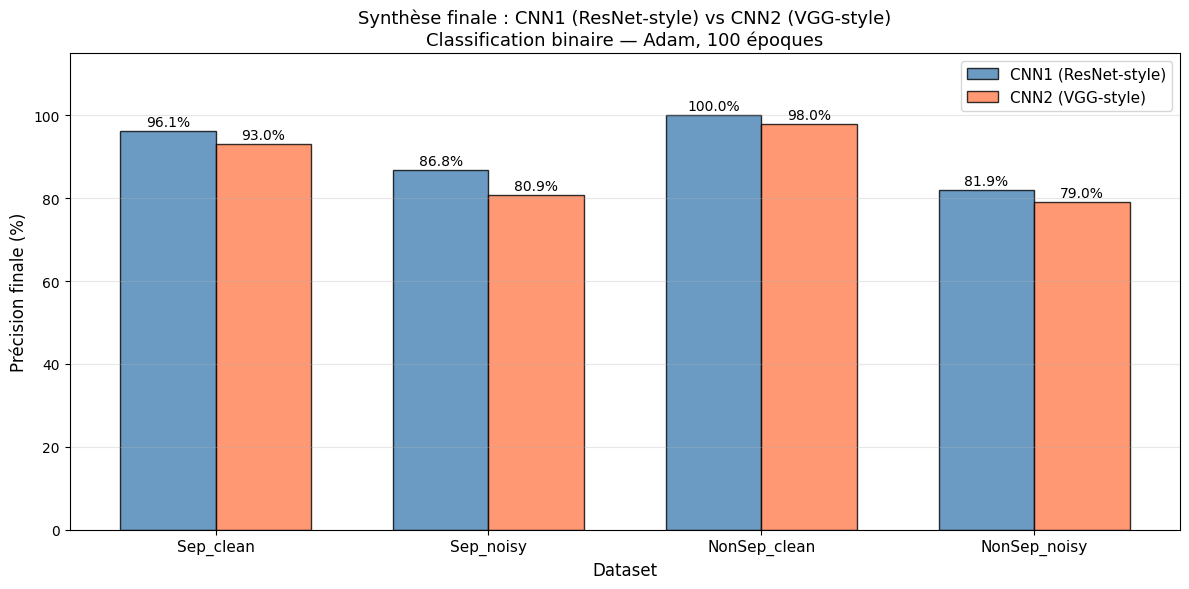


✓ NOTEBOOK COMPLET — Toutes les sections TP1 à TP5 exécutées

SECTIONS COUVERTES :
  TP1-V   : Visualisation des 4 datasets (PCA 2D)
  TP1-CN  : Covering Number adaptatif (ε relatif à l'étendue)
  TP2-SG  : Hinge Loss + sous-gradient (implémentation A à Z)
  TP2-D   : Justification dt = -gt (vs +gt)
  TP2-LS  : Armijo / Goldstein / Wolfe / pas fixe
  TP2-VAL : Régularisation L1 / L2 + validation train/val
  TP3     : 6 accélérateurs (SGD, Momentum, Nesterov, AdaGrad, RMSProp, Adam)
  TP3-C   : Comparaison globale CNN1 vs CNN2
  TP4-OSD : Online Subgradient Descent (pas constant/décroissant)
  TP4-SSG : 6 variantes stochastiques (batch, pas, ordre)
  TP5-A   : Perceptron, Perceptron normalisé, PA, OSD sur features CNN
  TP5-H   : Prediction with Expert Advice (Hedge)
  TP5-K   : Perceptron kernelisé (RBF, Polynomial, Linéaire)
  TP5-ND  : Normes usuelles et duales (L1, L2, L∞)
  TP5-REG : Régularisation online L1/L2, effet de λ



In [40]:
# ─── Graphique final de synthèse ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(names))
width = 0.35
acc_cnn1 = [results_final[n]['CNN1']['acc_final'] * 100 for n in names]
acc_cnn2 = [results_final[n]['CNN2']['acc_final'] * 100 for n in names]

bars1 = ax.bar(x_pos - width/2, acc_cnn1, width, label='CNN1 (ResNet-style)',
                color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, acc_cnn2, width, label='CNN2 (VGG-style)',
                color='coral', edgecolor='black', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Précision finale (%)", fontsize=12)
ax.set_title("Synthèse finale : CNN1 (ResNet-style) vs CNN2 (VGG-style)\n"
             "Classification binaire — Adam, 100 époques", fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("15_synthese_finale_CNN1_CNN2.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("✓ NOTEBOOK COMPLET — Toutes les sections TP1 à TP5 exécutées")
print("=" * 70)
print("""
SECTIONS COUVERTES :
  TP1-V   : Visualisation des 4 datasets (PCA 2D)
  TP1-CN  : Covering Number adaptatif (ε relatif à l'étendue)
  TP2-SG  : Hinge Loss + sous-gradient (implémentation A à Z)
  TP2-D   : Justification dt = -gt (vs +gt)
  TP2-LS  : Armijo / Goldstein / Wolfe / pas fixe
  TP2-VAL : Régularisation L1 / L2 + validation train/val
  TP3     : 6 accélérateurs (SGD, Momentum, Nesterov, AdaGrad, RMSProp, Adam)
  TP3-C   : Comparaison globale CNN1 vs CNN2
  TP4-OSD : Online Subgradient Descent (pas constant/décroissant)
  TP4-SSG : 6 variantes stochastiques (batch, pas, ordre)
  TP5-A   : Perceptron, Perceptron normalisé, PA, OSD sur features CNN
  TP5-H   : Prediction with Expert Advice (Hedge)
  TP5-K   : Perceptron kernelisé (RBF, Polynomial, Linéaire)
  TP5-ND  : Normes usuelles et duales (L1, L2, L∞)
  TP5-REG : Régularisation online L1/L2, effet de λ
""")
